# NLP Deep Learning Project Part 1  
Authors: Bezalel Spolter and Yair Shmueli

General Methodology:   
Imports, Import Data (Train and Validation) and Tokenize  
Method 1: Embed using GloVe method and then use LSTM for classification  
Method 2: Embed using Word2Vec method and then use GRU for classification  
Run Baseline DL model with same hyperparameters and then do tuning of hyperparameters using 10 random configurations.  
After finding best performing configuration (based on accuracy) save those models for use on test dataset.  

Hyperparameters and baseline configuration:
Batch Size: 64
Learning Rate: 0.001
Hidden Dimension size: 128
Dropout Rate: 0.5

## Imports

In [16]:
!pip install -U gensim

In [17]:
import torch
import torch.nn as nn
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torch.optim as optim
from collections import Counter
import re
from sklearn.metrics import accuracy_score
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import os
import random
from gensim.models import Word2Vec
from sklearn.model_selection import ParameterGrid


## Data Preparation and Tokenization

In [18]:
train_df = pd.read_csv("trainNLP.csv")
val_df = pd.read_csv("validationNLP.csv")


In [19]:

# --- 1. Define Helper Functions and Constants ---

# Assume you have 6 discrete classes (0 to 5)
NUM_CLASSES = 6
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
TEXT_COLUMN = "text"
LABEL_COLUMN = "label"

# Robust Tokenization Function
def tokenize(text: str):
    """Tokenizes text, performs basic cleaning, and returns a list of tokens."""
    text = str(text).lower()
    # Remove non-alphanumeric characters
    text = re.sub(r"[^a-zA-Z0-9]+", " ", text)
    tokens = text.strip().split()
    return tokens


# --- 2. Build Vocabulary ---

counter = Counter()
for t in train_df[TEXT_COLUMN]:
    counter.update(tokenize(t))

min_freq = 1 # Keeping all words
word2idx = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1,
}

for word, freq in counter.items():
    if freq >= min_freq and word not in word2idx:
        word2idx[word] = len(word2idx)

VOCAB_SIZE = len(word2idx)
print(f"Vocabulary size built on training data: {VOCAB_SIZE}")
# Renaming for consistency with original blocks
vocab = word2idx


# --- 3. Custom Dataset Class (REVISED to use explicit tokenization) ---

class TextDataset(Dataset):
    def __init__(self, df, word2idx):
        self.texts = df[TEXT_COLUMN].tolist()
        self.labels = df[LABEL_COLUMN].tolist()
        self.word2idx = word2idx

    def encode_text(self, text):
        tokens = tokenize(text)
        # Use UNK_TOKEN index (1) for any word not in the training vocab
        ids = [self.word2idx.get(tok, self.word2idx[UNK_TOKEN]) for tok in tokens]
        return torch.tensor(ids, dtype=torch.long)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x = self.encode_text(self.texts[idx])
        y = self.labels[idx]
        return x, torch.tensor(y, dtype=torch.long)

# --- 4. Custom Collate Function for Padding ---
# REQUIRED for correct batching of variable-length sequences.
def collate_fn(batch):
    sequences, labels = zip(*batch)
    pad_idx = word2idx[PAD_TOKEN]
    padded = pad_sequence(sequences, batch_first=True, padding_value=pad_idx)
    labels = torch.stack(labels)
    return padded, labels


# --- 5. Create Dataset objects (Final Prep) ---
train_dataset = TextDataset(train_df, word2idx)
val_dataset = TextDataset(val_df, word2idx)

print(f"Number of classes: {NUM_CLASSES}")


train_sequences = None
val_sequences = None
train_labels = None
val_labels = None

Vocabulary size built on training data: 15214
Number of classes: 6


## Method 1: GloVe Embedding and LSTM Classification

### GloVe Embedding

Here we downloaded existing pre-trained weights for this method of embedding from here:
https://nlp.stanford.edu/projects/glove/

In [20]:

# --- 1. Define GloVe Parameters ---
GLOVE_FILE_PATH = "glove.6B.100d.txt"

EMBEDDING_DIM = 100

# --- 2. Load GloVe and Create Embedding Matrix Function ---

def create_glove_embedding_matrix(glove_file_path, vocab, embed_dim):
    """Loads GloVe vectors and creates a PyTorch embedding matrix."""

    print(f"\nAttempting to load GloVe embeddings from: {glove_file_path}")

    # Initialize matrix: VOCAB_SIZE is available from Block 1 (len(vocab))
    embedding_matrix = np.zeros((len(vocab), embed_dim), dtype=np.float32)
    found_words = 0

    # Create an inverse vocabulary (index -> word) for convenience if needed later,
    # but primarily use vocab (word -> index)

    try:
        # Step 1: Read the GloVe file and map words to vectors
        word_to_vec = {}
        with open(glove_file_path, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                word = parts[0]
                vector = np.asarray(parts[1:], dtype='float32')

                # Check for vector integrity
                if len(vector) == embed_dim:
                    word_to_vec[word] = vector

        # Step 2: Populate the embedding matrix using the local vocabulary
        # The first two indices are <unk> (0) and <pad> (1)
        for word, idx in vocab.items():
            if word in word_to_vec:
                embedding_matrix[idx] = word_to_vec[word]
                found_words += 1
            # If word is not found (and is not <unk> or <pad>), it remains initialized as zeros.
            # <unk> and <pad> (indices 0 and 1) are also handled implicitly.

    except FileNotFoundError:
        print(f"\n--- FATAL ERROR: GloVe file not found at '{glove_file_path}' ---")
        print("Please ensure you have downloaded the GloVe file and updated GLOVE_FILE_PATH.")
        raise

    print(f"Found {found_words} out of {len(vocab)} words in GloVe vectors.")

    # Convert the numpy matrix to a PyTorch tensor
    return torch.from_numpy(embedding_matrix).float()

# --- 3. Execute Loading and Set Global Variable ---

EMBEDDING_WEIGHTS = create_glove_embedding_matrix(GLOVE_FILE_PATH, vocab, EMBEDDING_DIM).to(DEVICE)


Attempting to load GloVe embeddings from: glove.6B.100d.txt
Found 14212 out of 15214 words in GloVe vectors.


### LSTM Model Definition

In [21]:


class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, dropout, embedding_weights, bidirectional=False):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.num_directions = 2 if bidirectional else 1

        # 1. Embedding Layer: Initialize with pre-trained GloVe weights
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight = nn.Parameter(embedding_weights)

        # 2. LSTM Layer
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=1,
            batch_first=True,
            dropout=dropout, # Dropout is applied to the output of each layer *except* the last one
            bidirectional=bidirectional
        )

        # 3. Dropout Layer
        self.dropout = nn.Dropout(dropout)

        # 4. Fully Connected Layer for classification
        self.fc = nn.Linear(hidden_dim * self.num_directions, num_classes)

    def forward(self, text):
        # text shape: [batch size, seq len]
        embedded = self.embedding(text)
        # embedded shape: [batch size, seq len, embedding dim]

        # LSTM output:
        # output: [batch size, seq len, num_directions * hidden_dim]
        # (hidden, cell): [num_layers * num_directions, batch size, hidden_dim]
        output, (hidden, cell) = self.lstm(embedded)

        # Use the final hidden state for classification
        # If unidirectional, use the last layer's hidden state: hidden[-1, :, :]
        # If bidirectional, concatenate the last forward and last backward hidden states:
        if self.num_directions == 2:
            # Concatenate the final forward and backward hidden states
            final_hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            final_hidden = hidden[-1, :, :]

        # Apply dropout
        dropped = self.dropout(final_hidden)

        # Final classification
        out = self.fc(dropped)
        # out shape: [batch size, num_classes]

        return out

### Baseline Configuration

Helper function are needed for training the model and for defining configurations of hyper-parameters. In the baseline case we chose to use the hyper-parameters:
    batch_size': 64,
    'lr': 0.001,
    'hidden_dim': 128,
    'dropout': 0.5,

Running Configuration...

--- Running Config: {'batch_size': 64, 'lr': 0.001, 'hidden_dim': 128, 'dropout': 0.5} ---


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]


Early stopping triggered after 39 epochs.

FINAL VALIDATION CLASSIFICATION REPORT (Best Epoch)
              precision    recall  f1-score   support

     Class 0       0.95      0.96      0.96       550
     Class 1       0.93      0.95      0.94       704
     Class 2       0.91      0.81      0.86       178
     Class 3       0.90      0.96      0.93       275
     Class 4       0.88      0.86      0.87       212
     Class 5       0.84      0.75      0.79        81

    accuracy                           0.92      2000
   macro avg       0.90      0.88      0.89      2000
weighted avg       0.92      0.92      0.92      2000

Baseline Validation Accuracy: 0.9245


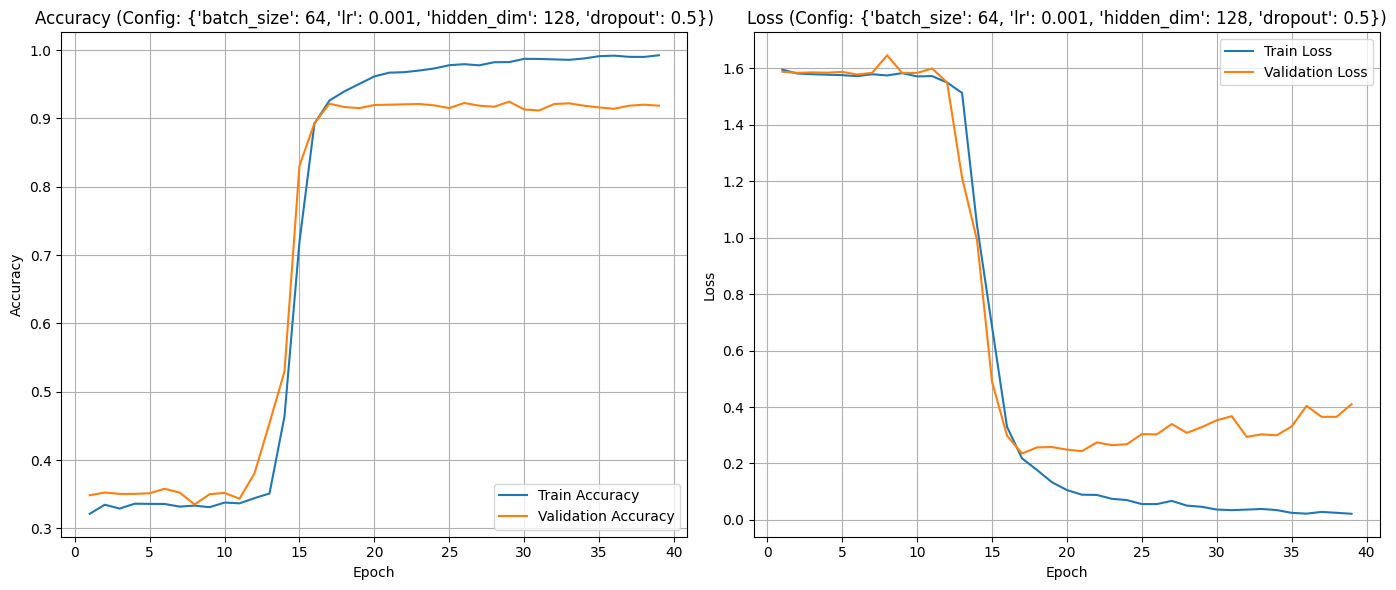

In [ ]:
def train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs, patience):

    # Store history for plotting
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    epochs_no_improve = 0

    # Variables to store data for the final report
    final_val_labels = []
    final_val_preds = []

    # Use tqdm for epoch progress bar
    for epoch in tqdm(range(num_epochs), desc="Epochs"):

        # --- Training Phase ---
        model.train()
        total_train_loss = 0
        all_train_preds = []
        all_train_labels = []

        for texts, labels in train_loader:
            texts, labels = texts.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()

            predictions = model(texts)
            loss = criterion(predictions, labels)

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

            # Calculate accuracy
            _, predicted = torch.max(predictions.data, 1)
            all_train_preds.extend(predicted.cpu().numpy())
            all_train_labels.extend(labels.cpu().numpy())

        avg_train_loss = total_train_loss / len(train_loader)
        train_acc = accuracy_score(all_train_labels, all_train_preds)


        # --- Validation Phase ---
        model.eval()
        total_val_loss = 0
        all_val_preds = []
        all_val_labels = []

        with torch.no_grad():
            for texts, labels in val_loader:
                texts, labels = texts.to(DEVICE), labels.to(DEVICE)

                predictions = model(texts)
                loss = criterion(predictions, labels)

                total_val_loss += loss.item()

                _, predicted = torch.max(predictions.data, 1)
                all_val_preds.extend(predicted.cpu().numpy())
                all_val_labels.extend(labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        val_acc = accuracy_score(all_val_labels, all_val_preds)

        # --- Logging and Early Stopping ---
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        # Save predictions and weights if this is the best epoch
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_no_improve = 0
            # Store the current validation labels and predictions for the final report
            final_val_labels = all_val_labels
            final_val_preds = all_val_preds
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                print(f"\nEarly stopping triggered after {epoch + 1} epochs.")
                break

    # ==========================================================
    # --- FINAL STEP: Print Classification Report ---
    # ==========================================================
    if final_val_labels:
        print("\n" + "="*50)
        print("FINAL VALIDATION CLASSIFICATION REPORT (Best Epoch)")
        print("="*50)

        # Note: Targets are 0 through 5 (6 classes)
        target_names = [f'Class {i}' for i in range(NUM_CLASSES)]

        print(classification_report(
            final_val_labels,
            final_val_preds,
            target_names=target_names,
            zero_division=0
        ))
    else:
        print("\nTraining completed, but no predictions were saved for the final report.")


    return best_val_acc, history


# --- 2. Define Helper Function: run_single_config ---
# This function trains model based on realization of values for hyper-parameters

def run_single_config(params, train_dataset, val_dataset, embedding_weights, num_epochs=100, patience=10, device=DEVICE):
    """Initializes and trains the model for a single configuration."""
    print(f"\n--- Running Config: {params} ---")

    # Create DataLoaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=params['batch_size'],
        shuffle=True,
        collate_fn=collate_fn
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=params['batch_size'],
        shuffle=False,
        collate_fn=collate_fn
    )
    # Initialize Model
    model = LSTMClassifier(
        VOCAB_SIZE,
        EMBEDDING_DIM,
        params['hidden_dim'],
        NUM_CLASSES,
        params['dropout'],
        embedding_weights
    ).to(device)

    # Initialize Optimizer and Loss
    optimizer = optim.Adam(model.parameters(), lr=params['lr'])
    criterion = nn.CrossEntropyLoss()

    # Train and Evaluate
    best_acc, history = train_model(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        num_epochs,
        patience
    )

    print(f"Baseline Validation Accuracy: {best_acc:.4f}")
    return history, params

# --- 3. Execute Baseline Run ---

# Baseline Configuration Values
BASELINE_PARAMS = {
    'batch_size': 64,
    'lr': 0.001,
    'hidden_dim': 128,
    'dropout': 0.5,
}

print("Running Configuration...")
baseline_history, baseline_params = run_single_config(
    BASELINE_PARAMS,
    train_dataset,
    val_dataset,
    EMBEDDING_WEIGHTS # These are the embedding weights from GloVe
)

# --- 4. Plotting the Results ---

epochs_run = len(baseline_history['train_acc'])
epochs_range = range(1, epochs_run + 1)

plt.figure(figsize=(14, 6))

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, baseline_history['train_acc'], label='Train Accuracy')
plt.plot(epochs_range, baseline_history['val_acc'], label='Validation Accuracy')
plt.title(f'Accuracy (Config: {baseline_params})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, baseline_history['train_loss'], label='Train Loss')
plt.plot(epochs_range, baseline_history['val_loss'], label='Validation Loss')
plt.title(f'Loss (Config: {baseline_params})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

We can see convergence to high accuracy and enough difference between train and validation to indicate no overfitting.

### Hyper-parameter Tuning

Generated 10 random configurations for tuning.

Starting Random Search Tuning...

--- Random Run 1/10: Params {'batch_size': 64, 'lr': 0.001, 'hidden_dim': 256, 'dropout': 0.3} ---

--- Running Config: {'batch_size': 64, 'lr': 0.001, 'hidden_dim': 256, 'dropout': 0.3} ---


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]


Early stopping triggered after 20 epochs.

FINAL VALIDATION CLASSIFICATION REPORT (Best Epoch)
              precision    recall  f1-score   support

     Class 0       0.95      0.97      0.96       550
     Class 1       0.94      0.93      0.94       704
     Class 2       0.82      0.85      0.83       178
     Class 3       0.91      0.94      0.92       275
     Class 4       0.88      0.90      0.89       212
     Class 5       0.98      0.70      0.82        81

    accuracy                           0.92      2000
   macro avg       0.91      0.88      0.89      2000
weighted avg       0.92      0.92      0.92      2000

Baseline Validation Accuracy: 0.9230


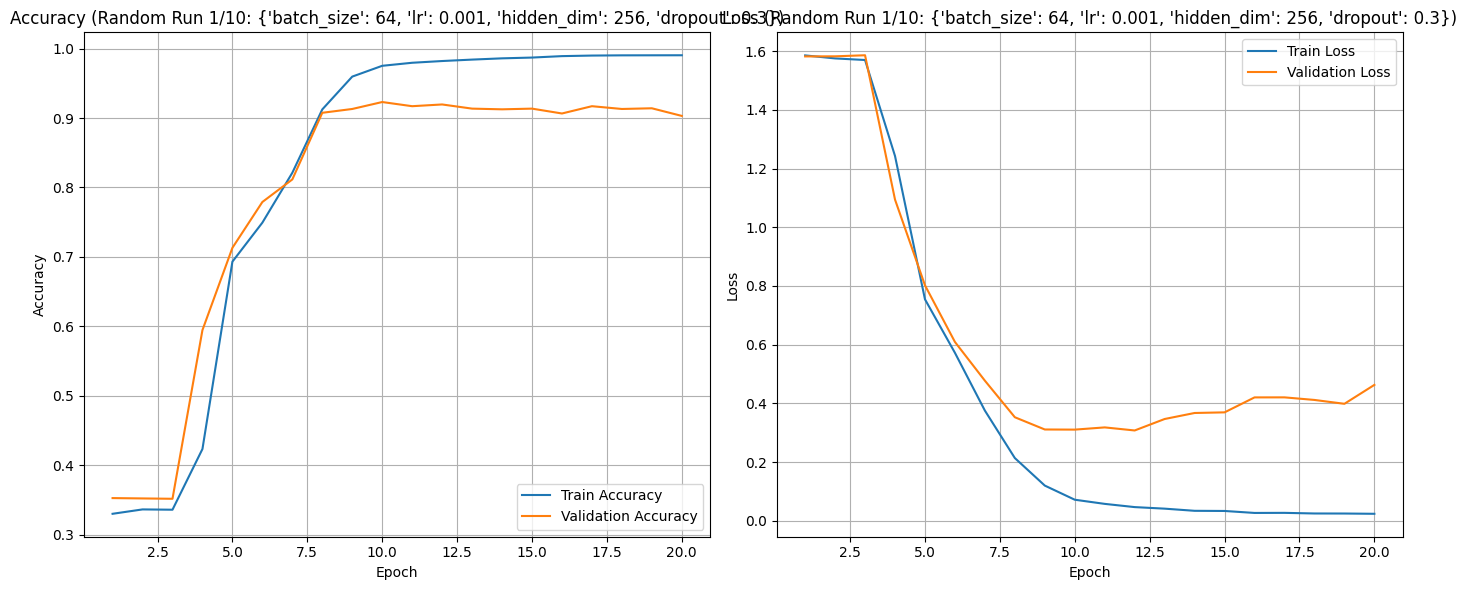

New Best Validation Accuracy: 0.9230

--- Random Run 2/10: Params {'batch_size': 32, 'lr': 0.005, 'hidden_dim': 64, 'dropout': 0.3} ---

--- Running Config: {'batch_size': 32, 'lr': 0.005, 'hidden_dim': 64, 'dropout': 0.3} ---


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]


Early stopping triggered after 15 epochs.

FINAL VALIDATION CLASSIFICATION REPORT (Best Epoch)
              precision    recall  f1-score   support

     Class 0       0.96      0.93      0.94       550
     Class 1       0.92      0.92      0.92       704
     Class 2       0.79      0.88      0.83       178
     Class 3       0.91      0.93      0.92       275
     Class 4       0.85      0.81      0.83       212
     Class 5       0.83      0.84      0.83        81

    accuracy                           0.91      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.91      0.91      0.91      2000

Baseline Validation Accuracy: 0.9060


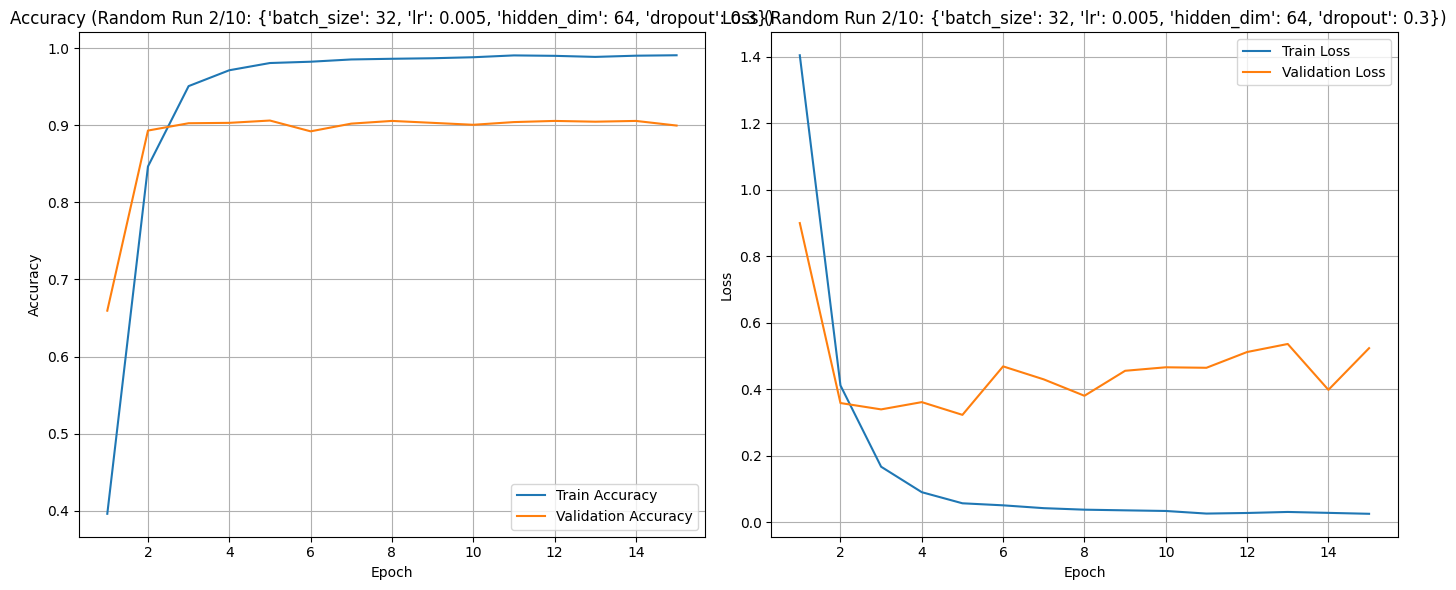


--- Random Run 3/10: Params {'batch_size': 64, 'lr': 0.005, 'hidden_dim': 128, 'dropout': 0.0} ---

--- Running Config: {'batch_size': 64, 'lr': 0.005, 'hidden_dim': 128, 'dropout': 0.0} ---


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]


Early stopping triggered after 16 epochs.

FINAL VALIDATION CLASSIFICATION REPORT (Best Epoch)
              precision    recall  f1-score   support

     Class 0       0.93      0.97      0.95       550
     Class 1       0.91      0.93      0.92       704
     Class 2       0.83      0.78      0.80       178
     Class 3       0.92      0.90      0.91       275
     Class 4       0.92      0.80      0.85       212
     Class 5       0.83      0.85      0.84        81

    accuracy                           0.91      2000
   macro avg       0.89      0.87      0.88      2000
weighted avg       0.91      0.91      0.91      2000

Baseline Validation Accuracy: 0.9075


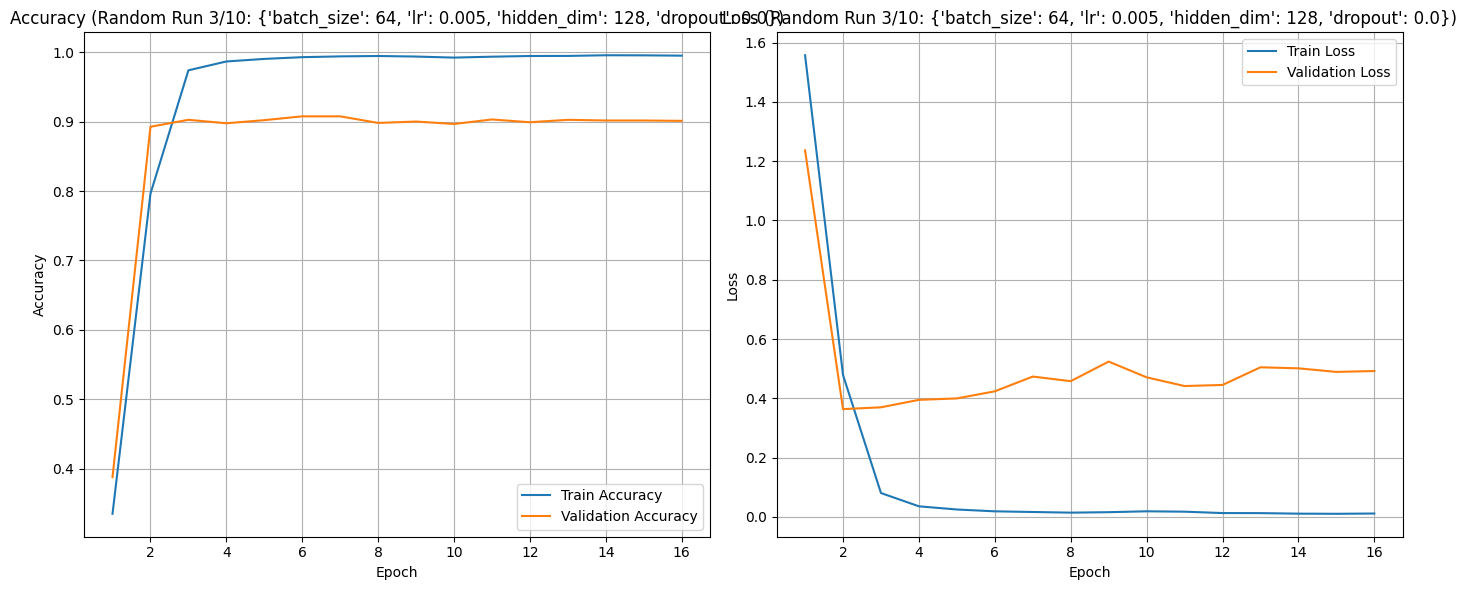


--- Random Run 4/10: Params {'batch_size': 64, 'lr': 0.01, 'hidden_dim': 128, 'dropout': 0.3} ---

--- Running Config: {'batch_size': 64, 'lr': 0.01, 'hidden_dim': 128, 'dropout': 0.3} ---


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]


Early stopping triggered after 14 epochs.

FINAL VALIDATION CLASSIFICATION REPORT (Best Epoch)
              precision    recall  f1-score   support

     Class 0       0.93      0.95      0.94       550
     Class 1       0.90      0.94      0.92       704
     Class 2       0.84      0.81      0.83       178
     Class 3       0.92      0.87      0.89       275
     Class 4       0.84      0.79      0.82       212
     Class 5       0.82      0.80      0.81        81

    accuracy                           0.90      2000
   macro avg       0.88      0.86      0.87      2000
weighted avg       0.90      0.90      0.90      2000

Baseline Validation Accuracy: 0.8990


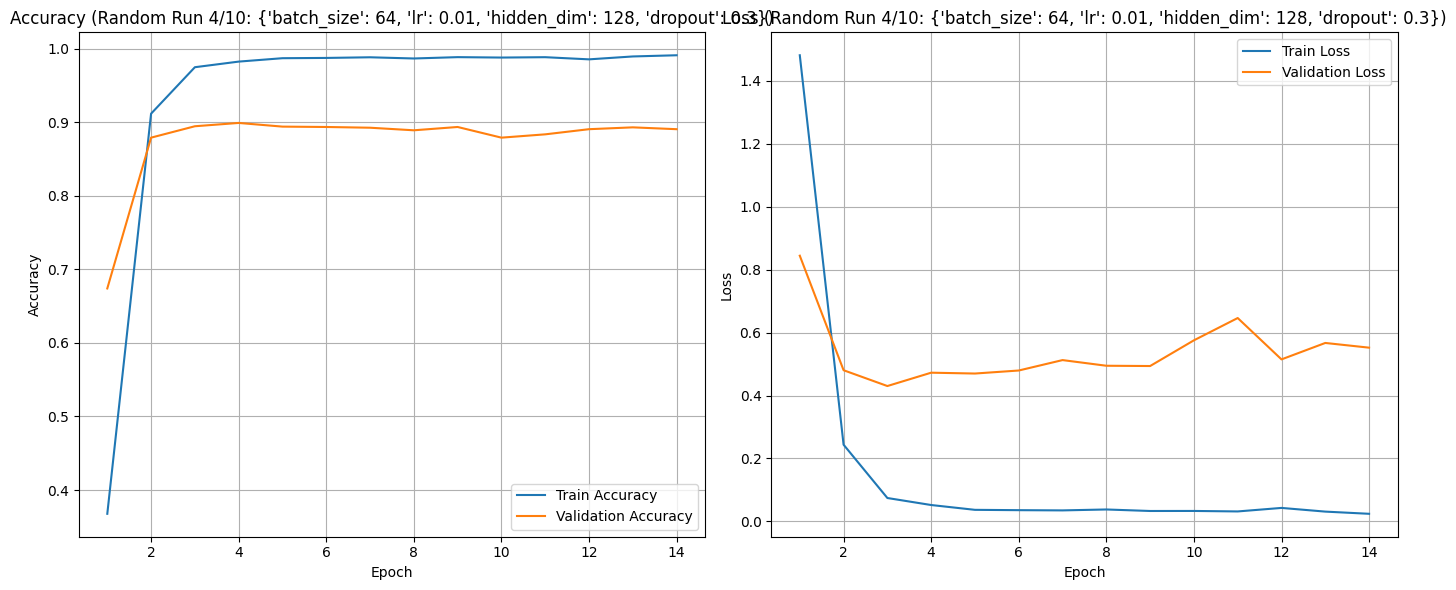


--- Random Run 5/10: Params {'batch_size': 64, 'lr': 0.01, 'hidden_dim': 128, 'dropout': 0.0} ---

--- Running Config: {'batch_size': 64, 'lr': 0.01, 'hidden_dim': 128, 'dropout': 0.0} ---


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]


Early stopping triggered after 12 epochs.

FINAL VALIDATION CLASSIFICATION REPORT (Best Epoch)
              precision    recall  f1-score   support

     Class 0       0.90      0.97      0.94       550
     Class 1       0.92      0.91      0.91       704
     Class 2       0.81      0.79      0.80       178
     Class 3       0.92      0.87      0.90       275
     Class 4       0.86      0.79      0.83       212
     Class 5       0.78      0.81      0.80        81

    accuracy                           0.89      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.89      0.89      0.89      2000

Baseline Validation Accuracy: 0.8930


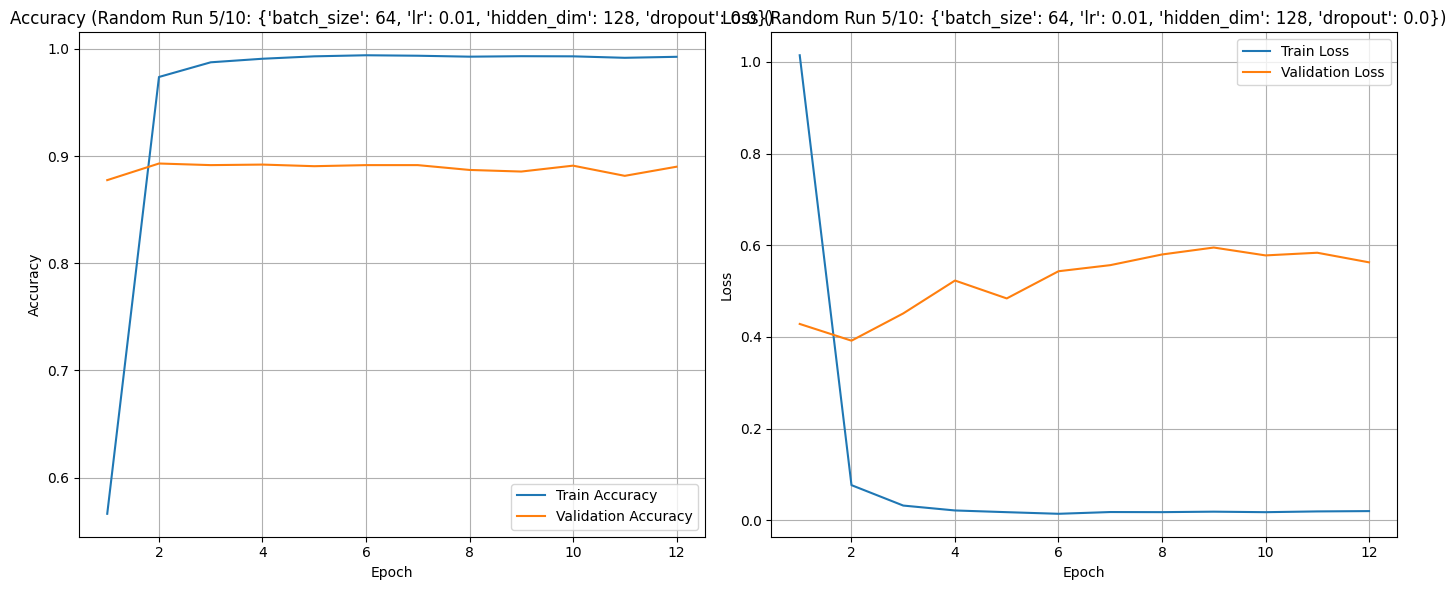


--- Random Run 6/10: Params {'batch_size': 32, 'lr': 0.005, 'hidden_dim': 256, 'dropout': 0.3} ---

--- Running Config: {'batch_size': 32, 'lr': 0.005, 'hidden_dim': 256, 'dropout': 0.3} ---


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]


Early stopping triggered after 15 epochs.

FINAL VALIDATION CLASSIFICATION REPORT (Best Epoch)
              precision    recall  f1-score   support

     Class 0       0.93      0.93      0.93       550
     Class 1       0.86      0.95      0.91       704
     Class 2       0.86      0.70      0.77       178
     Class 3       0.93      0.88      0.90       275
     Class 4       0.88      0.77      0.82       212
     Class 5       0.83      0.86      0.85        81

    accuracy                           0.89      2000
   macro avg       0.88      0.85      0.86      2000
weighted avg       0.89      0.89      0.89      2000

Baseline Validation Accuracy: 0.8900


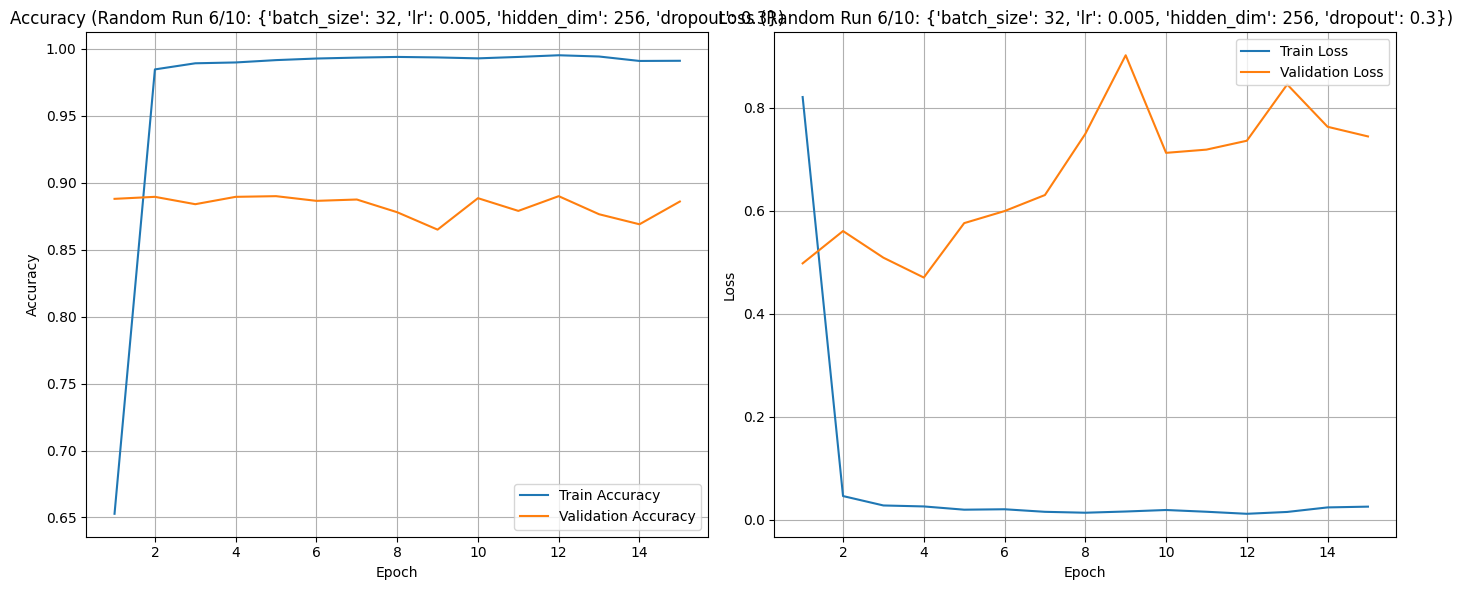


--- Random Run 7/10: Params {'batch_size': 64, 'lr': 0.005, 'hidden_dim': 256, 'dropout': 0.0} ---

--- Running Config: {'batch_size': 64, 'lr': 0.005, 'hidden_dim': 256, 'dropout': 0.0} ---


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]


Early stopping triggered after 23 epochs.

FINAL VALIDATION CLASSIFICATION REPORT (Best Epoch)
              precision    recall  f1-score   support

     Class 0       0.92      0.93      0.92       550
     Class 1       0.89      0.94      0.92       704
     Class 2       0.91      0.66      0.77       178
     Class 3       0.87      0.91      0.89       275
     Class 4       0.86      0.77      0.82       212
     Class 5       0.83      0.88      0.85        81

    accuracy                           0.89      2000
   macro avg       0.88      0.85      0.86      2000
weighted avg       0.89      0.89      0.89      2000

Baseline Validation Accuracy: 0.8900


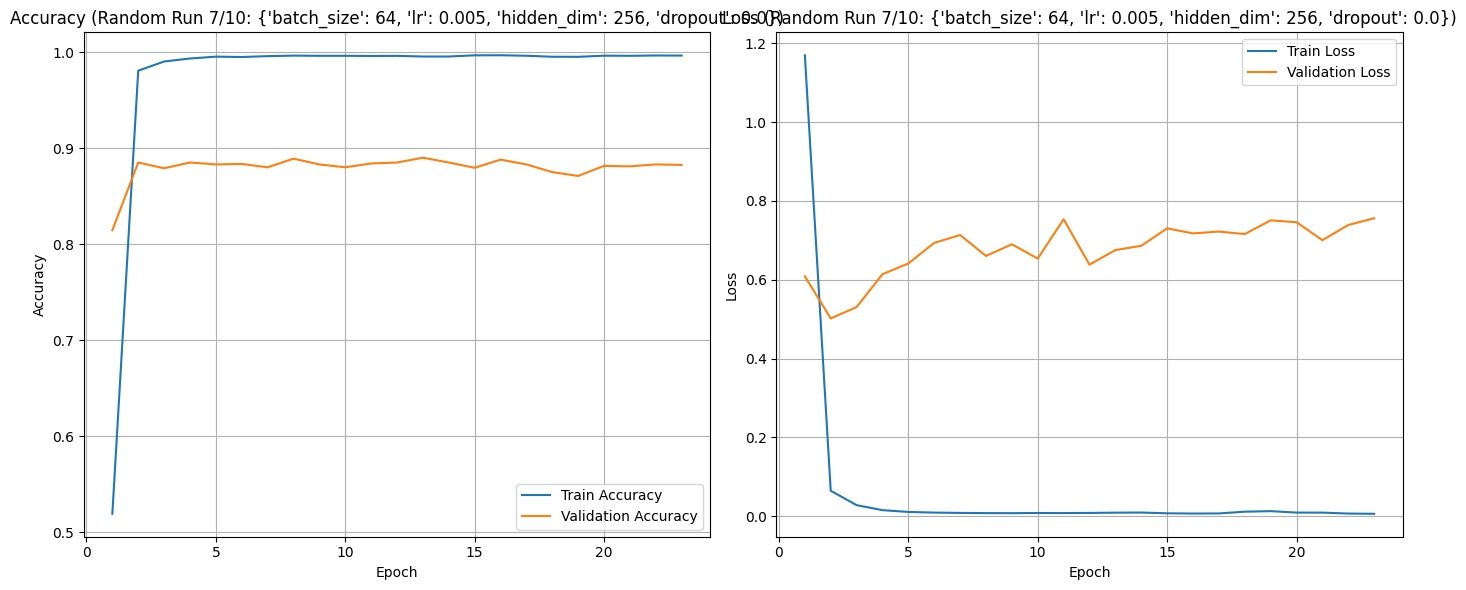


--- Random Run 8/10: Params {'batch_size': 32, 'lr': 0.01, 'hidden_dim': 256, 'dropout': 0.3} ---

--- Running Config: {'batch_size': 32, 'lr': 0.01, 'hidden_dim': 256, 'dropout': 0.3} ---


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]


Early stopping triggered after 11 epochs.

FINAL VALIDATION CLASSIFICATION REPORT (Best Epoch)
              precision    recall  f1-score   support

     Class 0       0.92      0.93      0.92       550
     Class 1       0.88      0.95      0.91       704
     Class 2       0.81      0.77      0.79       178
     Class 3       0.93      0.84      0.89       275
     Class 4       0.85      0.80      0.82       212
     Class 5       0.82      0.72      0.76        81

    accuracy                           0.89      2000
   macro avg       0.87      0.83      0.85      2000
weighted avg       0.89      0.89      0.88      2000

Baseline Validation Accuracy: 0.8860


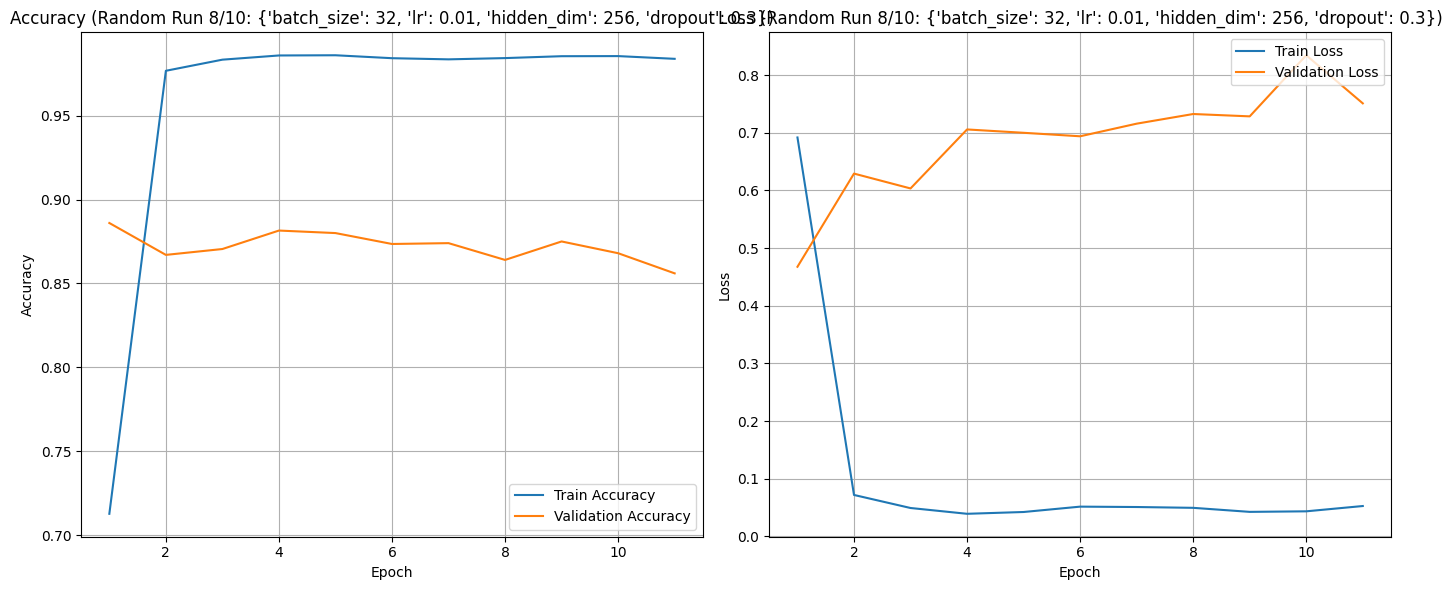


--- Random Run 9/10: Params {'batch_size': 64, 'lr': 0.01, 'hidden_dim': 64, 'dropout': 0.0} ---

--- Running Config: {'batch_size': 64, 'lr': 0.01, 'hidden_dim': 64, 'dropout': 0.0} ---


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]


Early stopping triggered after 12 epochs.

FINAL VALIDATION CLASSIFICATION REPORT (Best Epoch)
              precision    recall  f1-score   support

     Class 0       0.91      0.92      0.91       550
     Class 1       0.89      0.92      0.91       704
     Class 2       0.82      0.79      0.81       178
     Class 3       0.88      0.83      0.85       275
     Class 4       0.83      0.75      0.79       212
     Class 5       0.77      0.84      0.80        81

    accuracy                           0.88      2000
   macro avg       0.85      0.84      0.85      2000
weighted avg       0.88      0.88      0.88      2000

Baseline Validation Accuracy: 0.8760


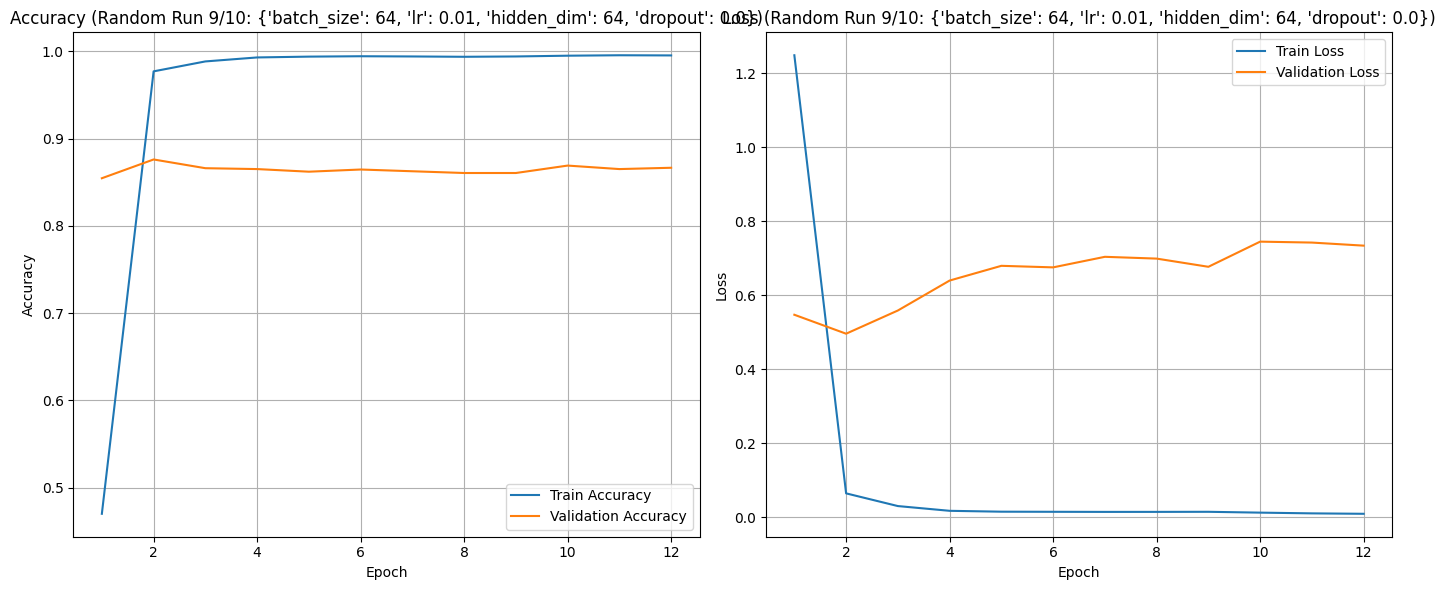


--- Random Run 10/10: Params {'batch_size': 64, 'lr': 0.005, 'hidden_dim': 64, 'dropout': 0.3} ---

--- Running Config: {'batch_size': 64, 'lr': 0.005, 'hidden_dim': 64, 'dropout': 0.3} ---


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]


Early stopping triggered after 21 epochs.

FINAL VALIDATION CLASSIFICATION REPORT (Best Epoch)
              precision    recall  f1-score   support

     Class 0       0.94      0.91      0.92       550
     Class 1       0.87      0.93      0.90       704
     Class 2       0.79      0.71      0.75       178
     Class 3       0.90      0.87      0.88       275
     Class 4       0.85      0.75      0.80       212
     Class 5       0.68      0.81      0.74        81

    accuracy                           0.87      2000
   macro avg       0.84      0.83      0.83      2000
weighted avg       0.87      0.87      0.87      2000

Baseline Validation Accuracy: 0.8730


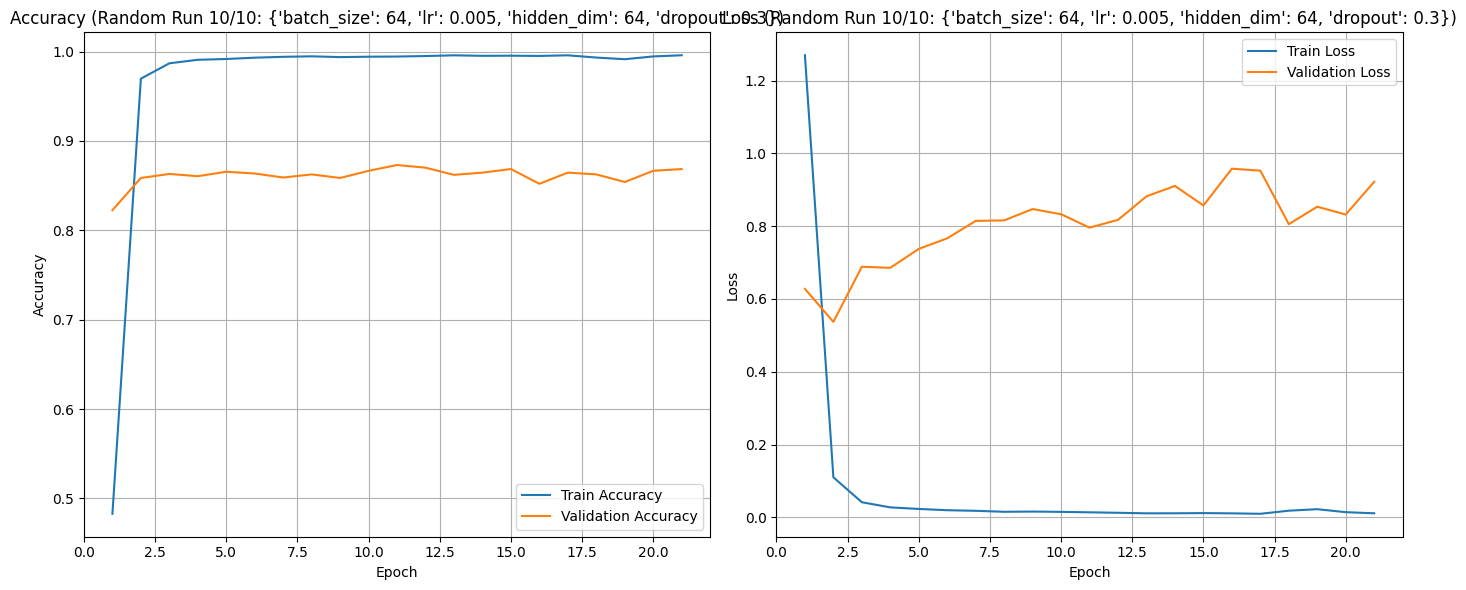

In [23]:
# --- 1. Hyper-parameter Value Options ---
HYPERPARAMETERS_SPACE = {
    'batch_size': [32, 64, 128],
    'lr': [0.001, 0.005, 0.01],
    'hidden_dim': [64, 128, 256],
    'dropout': [0.0, 0.3, 0.5],
}

NUM_RANDOM_RUNS = 10

# --- 2. Generate Random Configurations from Hyper-parameter options---
random_configs = []
for _ in range(NUM_RANDOM_RUNS):
    # Select a random value for each hyperparameter
    config = {k: random.choice(v) for k, v in HYPERPARAMETERS_SPACE.items()}
    random_configs.append(config)

print(f"Generated {NUM_RANDOM_RUNS} random configurations for tuning.")

# --- 3. Run Random Search ---

# Placeholder for the best run's results
best_random_val_accuracy = 0.0
best_random_params = None
best_random_history = None
all_run_summaries = []

print("\nStarting Random Search Tuning...")

for i, params in enumerate(random_configs):

    run_name = f"Random Run {i+1}/{NUM_RANDOM_RUNS}"
    print(f"\n--- {run_name}: Params {params} ---")

    # Run the configuration
    current_history, current_params = run_single_config(
        params,
        train_dataset,
        val_dataset,
        EMBEDDING_WEIGHTS,
        device=DEVICE
    )

    current_best_acc = max(current_history['val_acc'])
    all_run_summaries.append(f"Run {i+1} Acc: {current_best_acc:.4f} | Params: {current_params}")

    # --- PLOTTING FOR CURRENT RUN ---
    epochs_run = len(current_history['train_acc'])
    epochs_range = range(1, epochs_run + 1)

    plt.figure(figsize=(14, 6))

    # Plot 1: Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, current_history['train_acc'], label='Train Accuracy')
    plt.plot(epochs_range, current_history['val_acc'], label='Validation Accuracy')
    plt.title(f'Accuracy ({run_name}: {current_params})')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # Plot 2: Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, current_history['train_loss'], label='Train Loss')
    plt.plot(epochs_range, current_history['val_loss'], label='Validation Loss')
    plt.title(f'Loss ({run_name}: {current_params})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Check for best result
    if current_best_acc > best_random_val_accuracy:
        best_random_val_accuracy = current_best_acc
        best_random_params = current_params
        best_random_history = current_history
        print(f"New Best Validation Accuracy: {best_random_val_accuracy:.4f}")


Summary of tuning


--- Random Search Summary ---
Run 1 Acc: 0.9230 | Params: {'batch_size': 64, 'lr': 0.001, 'hidden_dim': 256, 'dropout': 0.3}
Run 2 Acc: 0.9060 | Params: {'batch_size': 32, 'lr': 0.005, 'hidden_dim': 64, 'dropout': 0.3}
Run 3 Acc: 0.9075 | Params: {'batch_size': 64, 'lr': 0.005, 'hidden_dim': 128, 'dropout': 0.0}
Run 4 Acc: 0.8990 | Params: {'batch_size': 64, 'lr': 0.01, 'hidden_dim': 128, 'dropout': 0.3}
Run 5 Acc: 0.8930 | Params: {'batch_size': 64, 'lr': 0.01, 'hidden_dim': 128, 'dropout': 0.0}
Run 6 Acc: 0.8900 | Params: {'batch_size': 32, 'lr': 0.005, 'hidden_dim': 256, 'dropout': 0.3}
Run 7 Acc: 0.8900 | Params: {'batch_size': 64, 'lr': 0.005, 'hidden_dim': 256, 'dropout': 0.0}
Run 8 Acc: 0.8860 | Params: {'batch_size': 32, 'lr': 0.01, 'hidden_dim': 256, 'dropout': 0.3}
Run 9 Acc: 0.8760 | Params: {'batch_size': 64, 'lr': 0.01, 'hidden_dim': 64, 'dropout': 0.0}
Run 10 Acc: 0.8730 | Params: {'batch_size': 64, 'lr': 0.005, 'hidden_dim': 64, 'dropout': 0.3}

Overall Best Random Accu

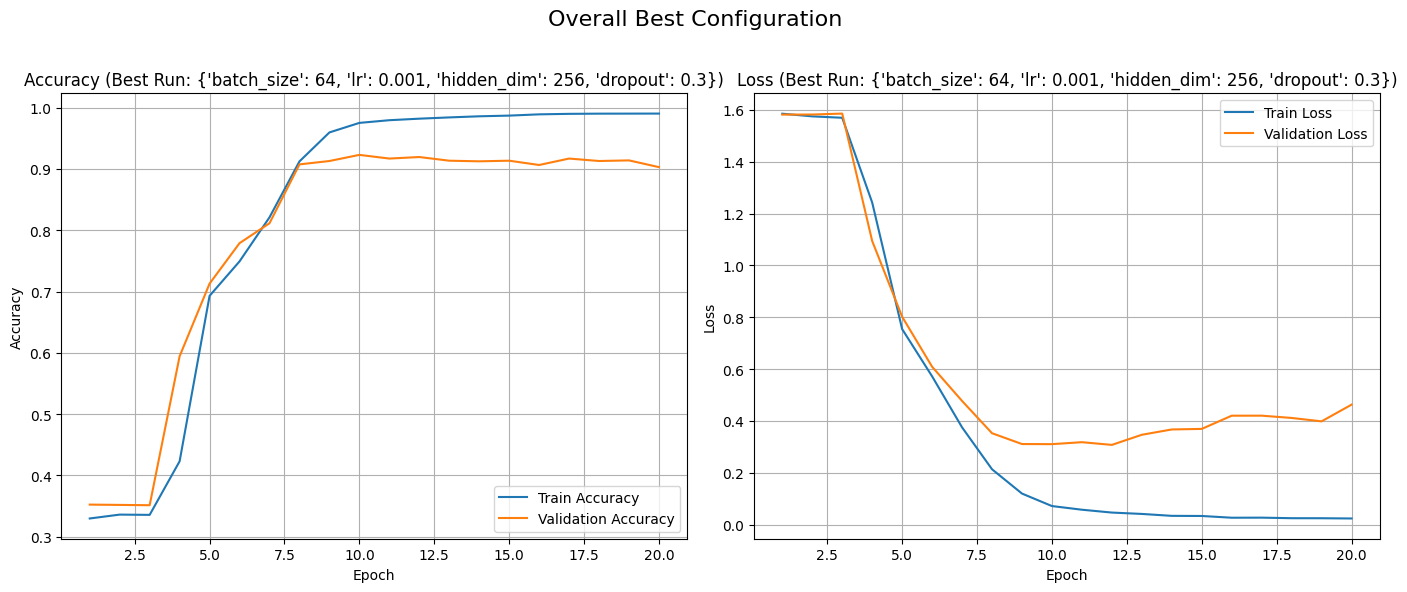

In [24]:

# --- 4. Summarize and Plot Overall Best Run ---
print("\n--- Random Search Summary ---")
for summary in all_run_summaries:
    print(summary)
print(f"\nOverall Best Random Accuracy: {best_random_val_accuracy:.4f}")
print(f"Best Random Hyperparameters: {best_random_params}")

if best_random_history:
    epochs_run = len(best_random_history['train_acc'])
    epochs_range = range(1, epochs_run + 1)

    plt.figure(figsize=(14, 6))
    plt.suptitle(f'Overall Best Configuration', fontsize=16)

    # Plot 1: Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, best_random_history['train_acc'], label='Train Accuracy')
    plt.plot(epochs_range, best_random_history['val_acc'], label='Validation Accuracy')
    plt.title(f'Accuracy (Best Run: {best_random_params})')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # Plot 2: Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, best_random_history['train_loss'], label='Train Loss')
    plt.plot(epochs_range, best_random_history['val_loss'], label='Validation Loss')
    plt.title(f'Loss (Best Run: {best_random_params})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

## Method 2: Word2Vec Embedding and GRU Classification

### Word2Vec Embedding

Here we tried to train and do embedding of Word2Vec ourselves

In [25]:

print("--- 1. Training Word2Vec on training texts ---")

# Tokenize all training texts to create the list of sentences needed by Word2Vec
sentences = [tokenize(t) for t in train_df[TEXT_COLUMN]]

# Train the Word2Vec model (Skip-gram, vector size 100)
w2v = Word2Vec(
    sentences=sentences,
    vector_size=100,      # Embedding dimension
    window=5,
    min_count=1,
    workers=4,
    sg=1                  # 1 = Skip-gram
)

# Set the embedding dimension variable
EMBEDDING_DIM = w2v.vector_size
print(f"Word2Vec embedding dimension (EMBEDDING_DIM): {EMBEDDING_DIM}")

print("--- 2. Creating Embedding Matrix ---")

# Initialize the embedding matrix
EMBEDDING_MATRIX_NP = np.zeros((VOCAB_SIZE, EMBEDDING_DIM), dtype="float32")

# Populate the matrix with W2V vectors
found_count = 0
for word, idx in vocab.items():
    if word == PAD_TOKEN:
        continue
    if word in w2v.wv.key_to_index:
        # Use the trained Word2Vec vector
        EMBEDDING_MATRIX_NP[idx] = w2v.wv[word]
        found_count += 1
    else:
        # Initialize out-of-vocabulary words (OOB) with random noise
        EMBEDDING_MATRIX_NP[idx] = np.random.normal(scale=0.6, size=(EMBEDDING_DIM,))

# Handle the UNK token (index 1): set it to the average of all other found vectors
# (Excluding PAD at index 0 and ignoring any random vectors initialized above)
if VOCAB_SIZE > 2:
    unk_idx = vocab[UNK_TOKEN]
    EMBEDDING_MATRIX_NP[unk_idx] = np.mean(EMBEDDING_MATRIX_NP[2:], axis=0)

print(f"Embedding matrix shape: {EMBEDDING_MATRIX_NP.shape}")
print(f"Words found in W2V model: {found_count}")

# Convert the NumPy matrix to a PyTorch tensor, ready for the model
EMBEDDING_WEIGHTS = torch.from_numpy(EMBEDDING_MATRIX_NP).float().to(DEVICE)

--- 1. Training Word2Vec on training texts ---
Word2Vec embedding dimension (EMBEDDING_DIM): 100
--- 2. Creating Embedding Matrix ---
Embedding matrix shape: (15214, 100)
Words found in W2V model: 15212


### GRU Model Definition

In [26]:
class GRUClassifier(nn.Module):
    def __init__(self,
                 vocab_size,
                 embedding_dim,
                 hidden_dim,
                 num_classes,
                 embedding_matrix, # PyTorch tensor of W2V weights
                 num_layers=1,
                 bidirectional=True,
                 dropout=0.3,
                 pad_idx=0):
        super().__init__()

        # 1. Embedding Layer: Load the pre-trained W2V weights
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_idx
        )
        # Copy W2V weights into the embedding layer
        self.embedding.weight.data.copy_(embedding_matrix)

        self.num_directions = 2 if bidirectional else 1

        # 2. GRU Layer
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            # Dropout is only applied between layers, so set to 0.0 if num_layers=1
            dropout=dropout if num_layers > 1 else 0.0,
        )

        gru_output_dim = hidden_dim * self.num_directions

        # 3. Final Classification
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(gru_output_dim, num_classes)
        )

        self.bidirectional = bidirectional

    def forward(self, x):
        # x shape: [batch size, seq len]
        embedded = self.embedding(x)
        # embedded shape: [batch size, seq len, embedding dim]

        # outputs: [batch size, seq len, num_directions * hidden_dim]
        # hidden: [num_layers * num_directions, batch size, hidden_dim]
        outputs, hidden = self.gru(embedded)

        # Use the final hidden state for classification
        if self.bidirectional:
            # Concatenate the final forward (hidden[-2]) and backward (hidden[-1]) states
            final_hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            final_hidden = hidden[-1]

        # final_hidden shape: [batch size, gru_output_dim]
        logits = self.fc(final_hidden)
        return logits

### Baseline Configuration

Running GRU + Word2Vec Baseline Configuration...

--- Running GRU Config: {'batch_size': 64, 'lr': 0.001, 'hidden_dim': 128, 'dropout': 0.5} ---


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]


Early stopping triggered after 19 epochs.

FINAL VALIDATION CLASSIFICATION REPORT (Best Epoch)
              precision    recall  f1-score   support

     Class 0       0.94      0.95      0.95       550
     Class 1       0.93      0.96      0.94       704
     Class 2       0.84      0.80      0.82       178
     Class 3       0.93      0.91      0.92       275
     Class 4       0.91      0.86      0.88       212
     Class 5       0.85      0.85      0.85        81

    accuracy                           0.92      2000
   macro avg       0.90      0.89      0.89      2000
weighted avg       0.92      0.92      0.92      2000

GRU Validation Accuracy: 0.9205


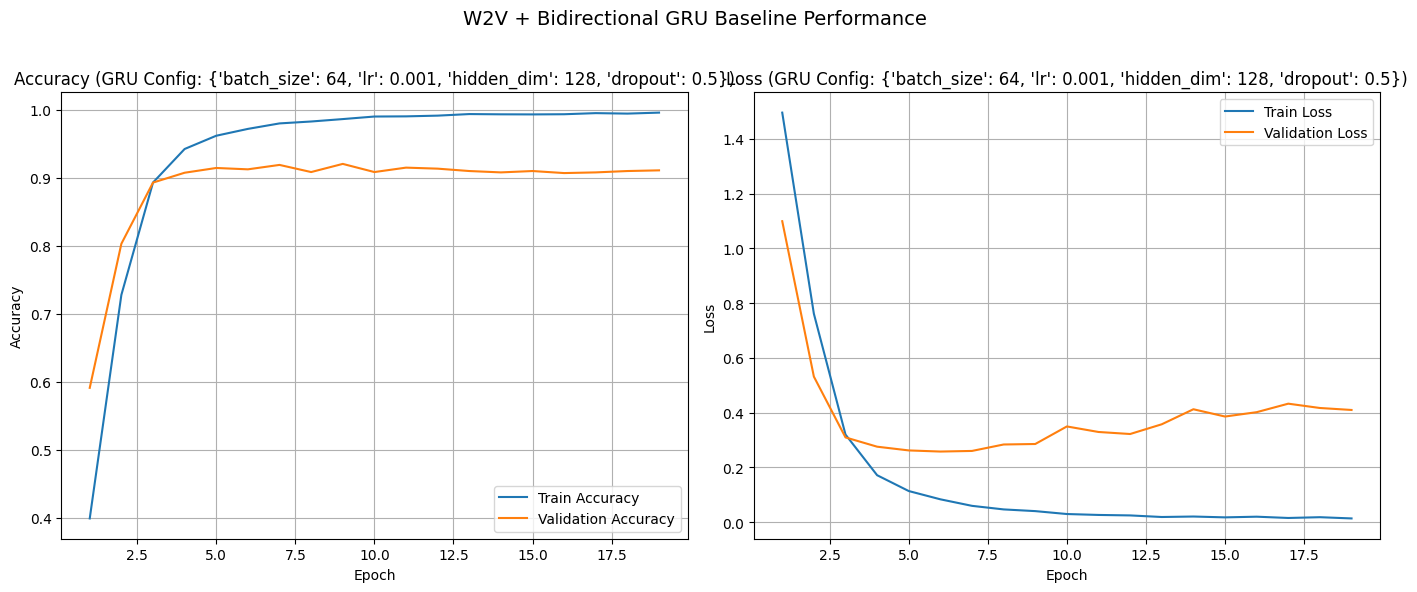

In [27]:
# --- 1. Define the Baseline Configuration ---
BASELINE_PARAMS_GRU = {
    'batch_size': 64,
    'lr': 0.001,
    'hidden_dim': 128,
    'dropout': 0.5,
}

print("Running GRU + Word2Vec Baseline Configuration...")

# --- 2. Create DataLoaders ---
def create_dataloaders_gru(batch_size):
    # NOTE: Requires train_dataset, val_dataset, and collate_fn to be defined
    from torch.utils.data import DataLoader
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn
    )
    return train_loader, val_loader

# --- 3. Execute Baseline Run ---

def run_single_config_gru(params, embedding_weights, num_epochs=100, patience=10, device=DEVICE):
    """Initializes and trains the GRU model for a single configuration."""
    print(f"\n--- Running GRU Config: {params} ---")

    train_loader, val_loader = create_dataloaders_gru(params['batch_size'])

    # Initialize GRU Model
    # NOTE: This assumes GRUClassifier accepts the PyTorch Tensor embedding_weights
    model = GRUClassifier(
        VOCAB_SIZE,
        EMBEDDING_DIM,
        params['hidden_dim'],
        NUM_CLASSES,
        embedding_weights,
        bidirectional=True,
        dropout=params['dropout'],
        pad_idx=word2idx[PAD_TOKEN]
    ).to(device)

    # Initialize Optimizer and Loss
    import torch.optim as optim # Ensure optim is imported
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=params['lr'])

    # Train and Evaluate (This call triggers the classification report printout)
    best_acc, history = train_model(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        num_epochs,
        patience
    )

    print(f"GRU Validation Accuracy: {best_acc:.4f}")
    return history, params

baseline_history_gru, baseline_params_gru = run_single_config_gru(
    BASELINE_PARAMS_GRU,
    EMBEDDING_WEIGHTS
)

# --- 4. Plotting the Baseline Results ---

epochs_run = len(baseline_history_gru['train_acc'])
epochs_range = range(1, epochs_run + 1)

plt.figure(figsize=(14, 6))
plt.suptitle('W2V + Bidirectional GRU Baseline Performance', fontsize=14)

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, baseline_history_gru['train_acc'], label='Train Accuracy')
plt.plot(epochs_range, baseline_history_gru['val_acc'], label='Validation Accuracy')
plt.title(f'Accuracy (GRU Config: {baseline_params_gru})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, baseline_history_gru['train_loss'], label='Train Loss')
plt.plot(epochs_range, baseline_history_gru['val_loss'], label='Validation Loss')
plt.title(f'Loss (GRU Config: {baseline_params_gru})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

We can see convergence to high accuracy and enough difference between train and validation to indicate no overfitting.

### Hyper-parameter Tuning

Generated 10 random configurations for GRU tuning.

Starting GRU Random Search Tuning...

--- GRU Random Run 1/10: Params {'batch_size': 32, 'lr': 0.005, 'hidden_dim': 256, 'dropout': 0.5} ---

--- Running GRU Config: {'batch_size': 32, 'lr': 0.005, 'hidden_dim': 256, 'dropout': 0.5} ---


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]


Early stopping triggered after 13 epochs.

FINAL VALIDATION CLASSIFICATION REPORT (Best Epoch)
              precision    recall  f1-score   support

     Class 0       0.95      0.96      0.96       550
     Class 1       0.96      0.92      0.94       704
     Class 2       0.81      0.93      0.87       178
     Class 3       0.97      0.91      0.94       275
     Class 4       0.82      0.92      0.87       212
     Class 5       0.92      0.75      0.83        81

    accuracy                           0.93      2000
   macro avg       0.91      0.90      0.90      2000
weighted avg       0.93      0.93      0.93      2000

GRU Validation Accuracy: 0.9260


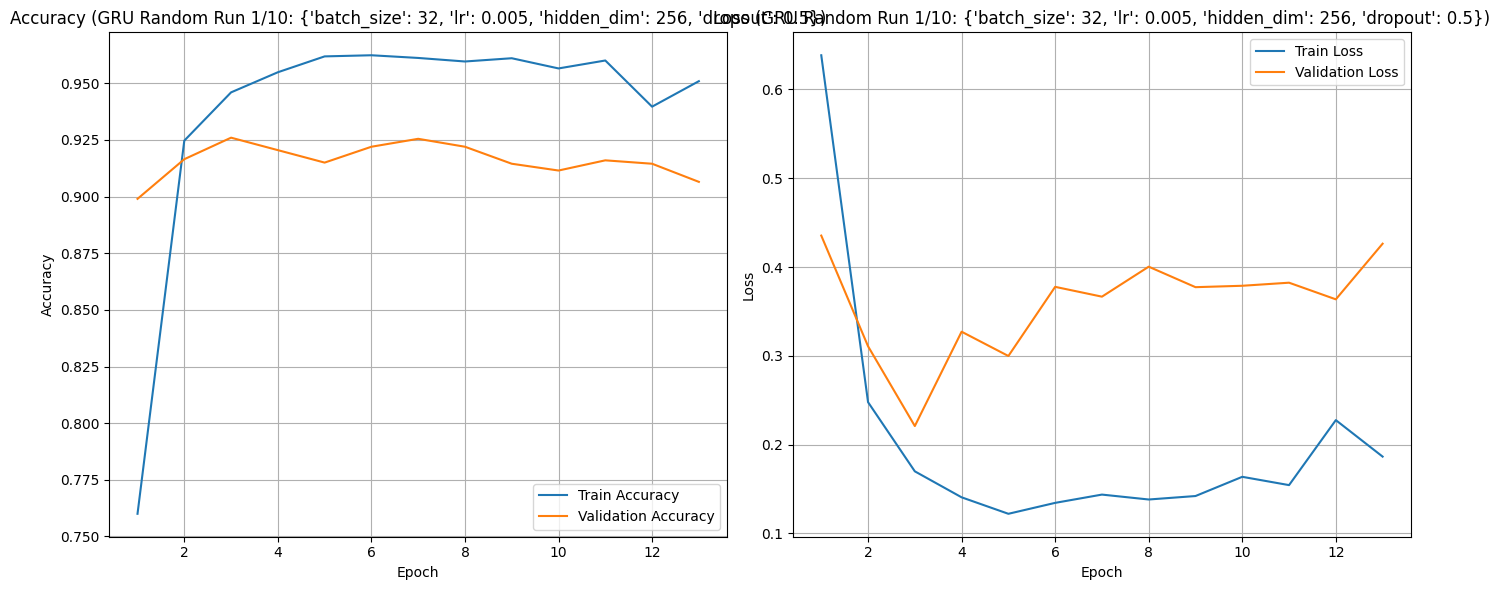

New Best Validation Accuracy: 0.9260

--- GRU Random Run 2/10: Params {'batch_size': 128, 'lr': 0.005, 'hidden_dim': 256, 'dropout': 0.3} ---

--- Running GRU Config: {'batch_size': 128, 'lr': 0.005, 'hidden_dim': 256, 'dropout': 0.3} ---


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]


Early stopping triggered after 12 epochs.

FINAL VALIDATION CLASSIFICATION REPORT (Best Epoch)
              precision    recall  f1-score   support

     Class 0       0.96      0.95      0.96       550
     Class 1       0.94      0.97      0.95       704
     Class 2       0.90      0.83      0.86       178
     Class 3       0.92      0.95      0.94       275
     Class 4       0.94      0.79      0.86       212
     Class 5       0.74      0.91      0.82        81

    accuracy                           0.93      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.93      0.93      0.93      2000

GRU Validation Accuracy: 0.9285


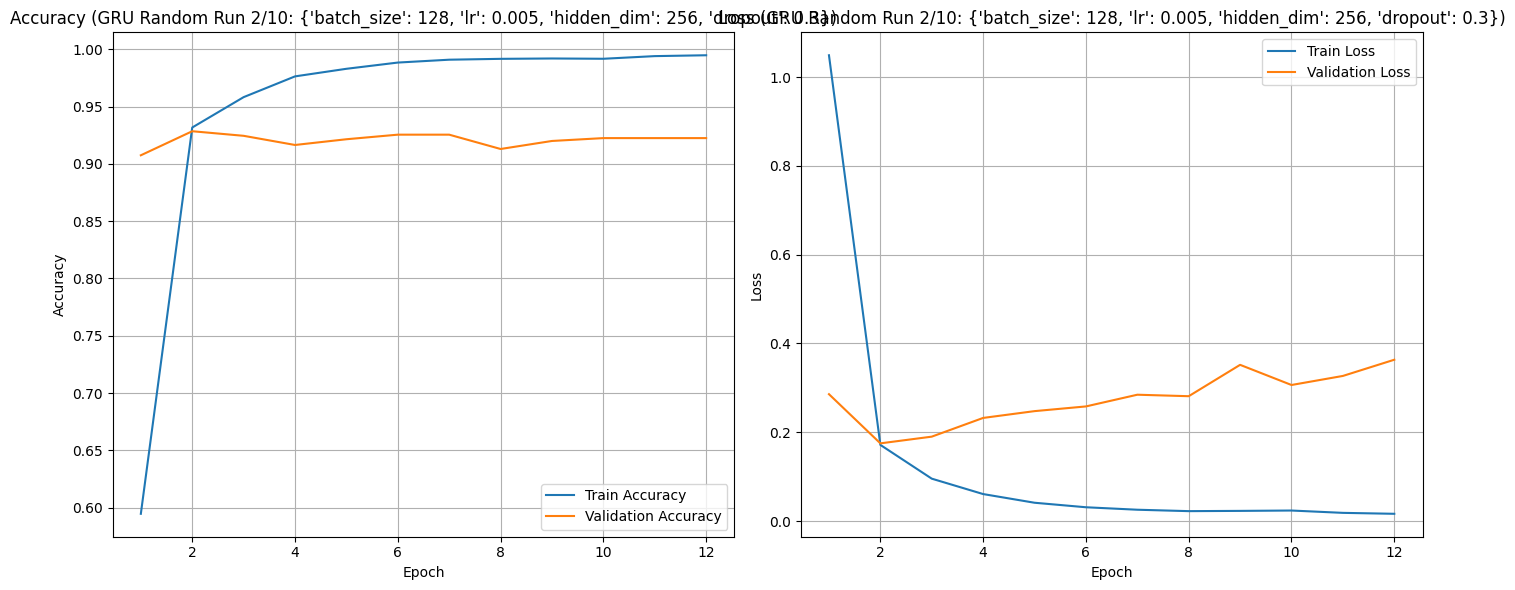

New Best Validation Accuracy: 0.9285

--- GRU Random Run 3/10: Params {'batch_size': 64, 'lr': 0.001, 'hidden_dim': 128, 'dropout': 0.3} ---

--- Running GRU Config: {'batch_size': 64, 'lr': 0.001, 'hidden_dim': 128, 'dropout': 0.3} ---


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]


Early stopping triggered after 16 epochs.

FINAL VALIDATION CLASSIFICATION REPORT (Best Epoch)
              precision    recall  f1-score   support

     Class 0       0.93      0.97      0.95       550
     Class 1       0.93      0.95      0.94       704
     Class 2       0.84      0.79      0.81       178
     Class 3       0.98      0.89      0.94       275
     Class 4       0.89      0.87      0.88       212
     Class 5       0.80      0.81      0.81        81

    accuracy                           0.92      2000
   macro avg       0.90      0.88      0.89      2000
weighted avg       0.92      0.92      0.92      2000

GRU Validation Accuracy: 0.9200


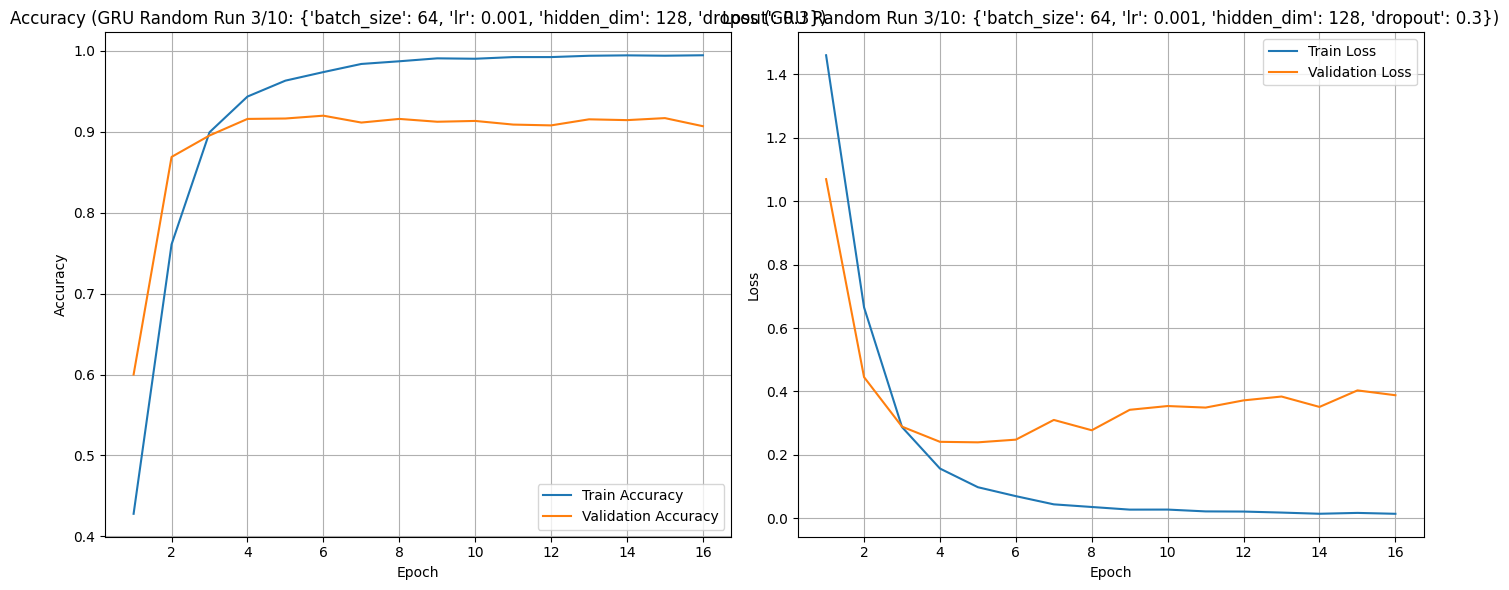


--- GRU Random Run 4/10: Params {'batch_size': 128, 'lr': 0.005, 'hidden_dim': 128, 'dropout': 0.5} ---

--- Running GRU Config: {'batch_size': 128, 'lr': 0.005, 'hidden_dim': 128, 'dropout': 0.5} ---


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]


Early stopping triggered after 21 epochs.

FINAL VALIDATION CLASSIFICATION REPORT (Best Epoch)
              precision    recall  f1-score   support

     Class 0       0.95      0.97      0.96       550
     Class 1       0.95      0.93      0.94       704
     Class 2       0.80      0.87      0.84       178
     Class 3       0.94      0.93      0.94       275
     Class 4       0.91      0.86      0.88       212
     Class 5       0.84      0.81      0.82        81

    accuracy                           0.93      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.93      0.93      0.93      2000

GRU Validation Accuracy: 0.9255


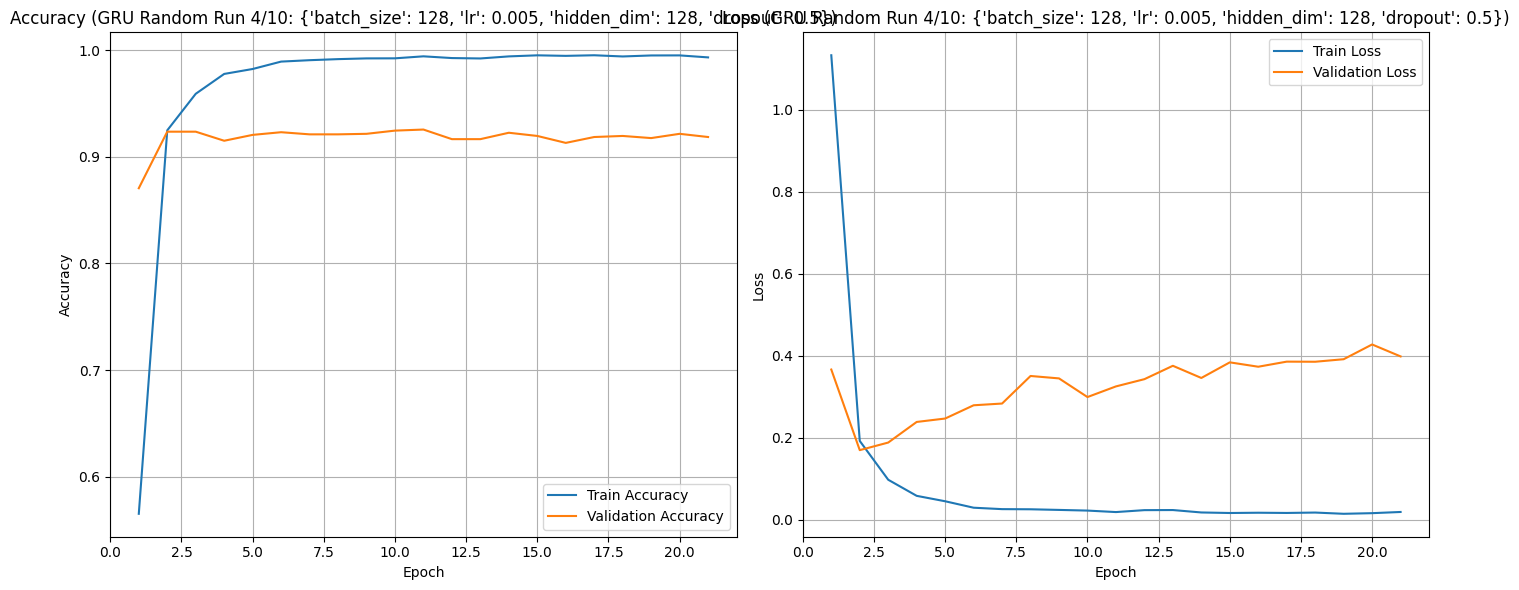


--- GRU Random Run 5/10: Params {'batch_size': 128, 'lr': 0.01, 'hidden_dim': 128, 'dropout': 0.5} ---

--- Running GRU Config: {'batch_size': 128, 'lr': 0.01, 'hidden_dim': 128, 'dropout': 0.5} ---


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]


Early stopping triggered after 12 epochs.

FINAL VALIDATION CLASSIFICATION REPORT (Best Epoch)
              precision    recall  f1-score   support

     Class 0       0.96      0.97      0.96       550
     Class 1       0.94      0.97      0.95       704
     Class 2       0.92      0.76      0.83       178
     Class 3       0.90      0.97      0.93       275
     Class 4       0.90      0.82      0.86       212
     Class 5       0.84      0.86      0.85        81

    accuracy                           0.93      2000
   macro avg       0.91      0.89      0.90      2000
weighted avg       0.93      0.93      0.93      2000

GRU Validation Accuracy: 0.9280


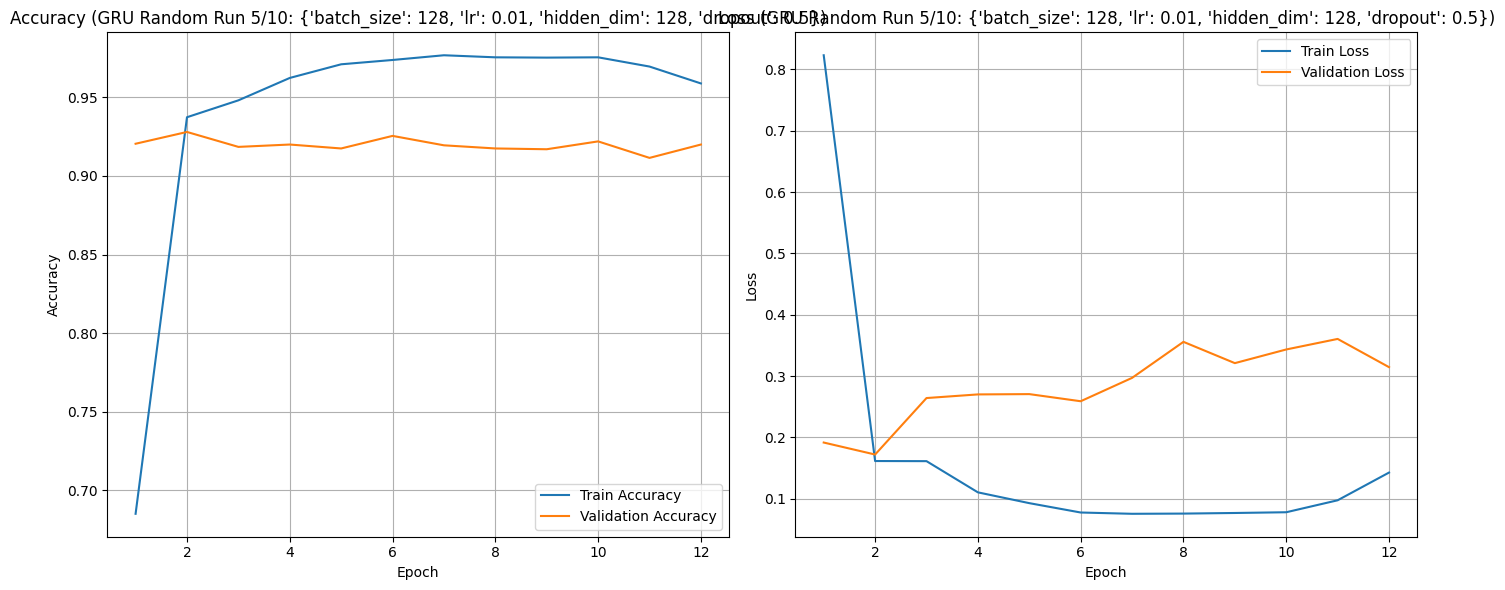


--- GRU Random Run 6/10: Params {'batch_size': 64, 'lr': 0.01, 'hidden_dim': 128, 'dropout': 0.3} ---

--- Running GRU Config: {'batch_size': 64, 'lr': 0.01, 'hidden_dim': 128, 'dropout': 0.3} ---


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]


Early stopping triggered after 15 epochs.

FINAL VALIDATION CLASSIFICATION REPORT (Best Epoch)
              precision    recall  f1-score   support

     Class 0       0.92      0.98      0.95       550
     Class 1       0.93      0.95      0.94       704
     Class 2       0.96      0.75      0.84       178
     Class 3       0.92      0.93      0.93       275
     Class 4       0.89      0.86      0.88       212
     Class 5       0.90      0.77      0.83        81

    accuracy                           0.92      2000
   macro avg       0.92      0.88      0.89      2000
weighted avg       0.92      0.92      0.92      2000

GRU Validation Accuracy: 0.9235


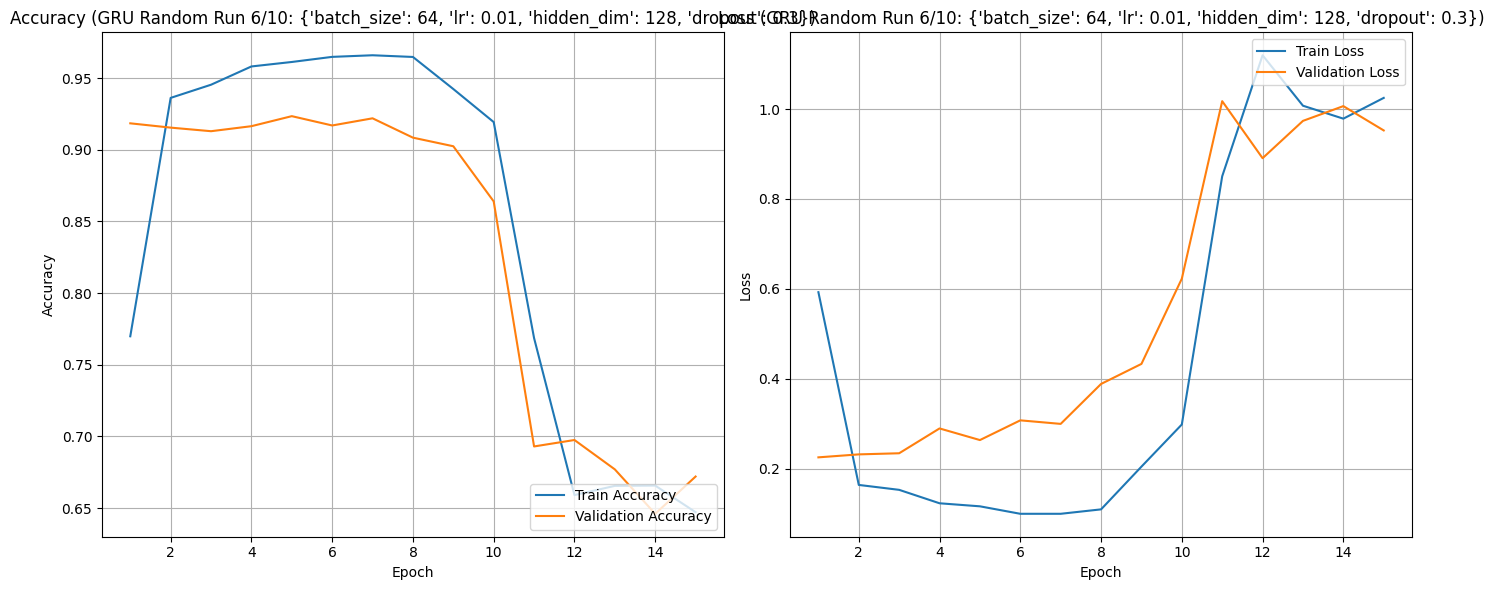


--- GRU Random Run 7/10: Params {'batch_size': 32, 'lr': 0.001, 'hidden_dim': 128, 'dropout': 0.0} ---

--- Running GRU Config: {'batch_size': 32, 'lr': 0.001, 'hidden_dim': 128, 'dropout': 0.0} ---


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]


Early stopping triggered after 14 epochs.

FINAL VALIDATION CLASSIFICATION REPORT (Best Epoch)
              precision    recall  f1-score   support

     Class 0       0.94      0.98      0.96       550
     Class 1       0.94      0.95      0.94       704
     Class 2       0.87      0.80      0.83       178
     Class 3       0.95      0.92      0.94       275
     Class 4       0.90      0.87      0.89       212
     Class 5       0.84      0.78      0.81        81

    accuracy                           0.93      2000
   macro avg       0.90      0.88      0.89      2000
weighted avg       0.92      0.93      0.92      2000

GRU Validation Accuracy: 0.9250


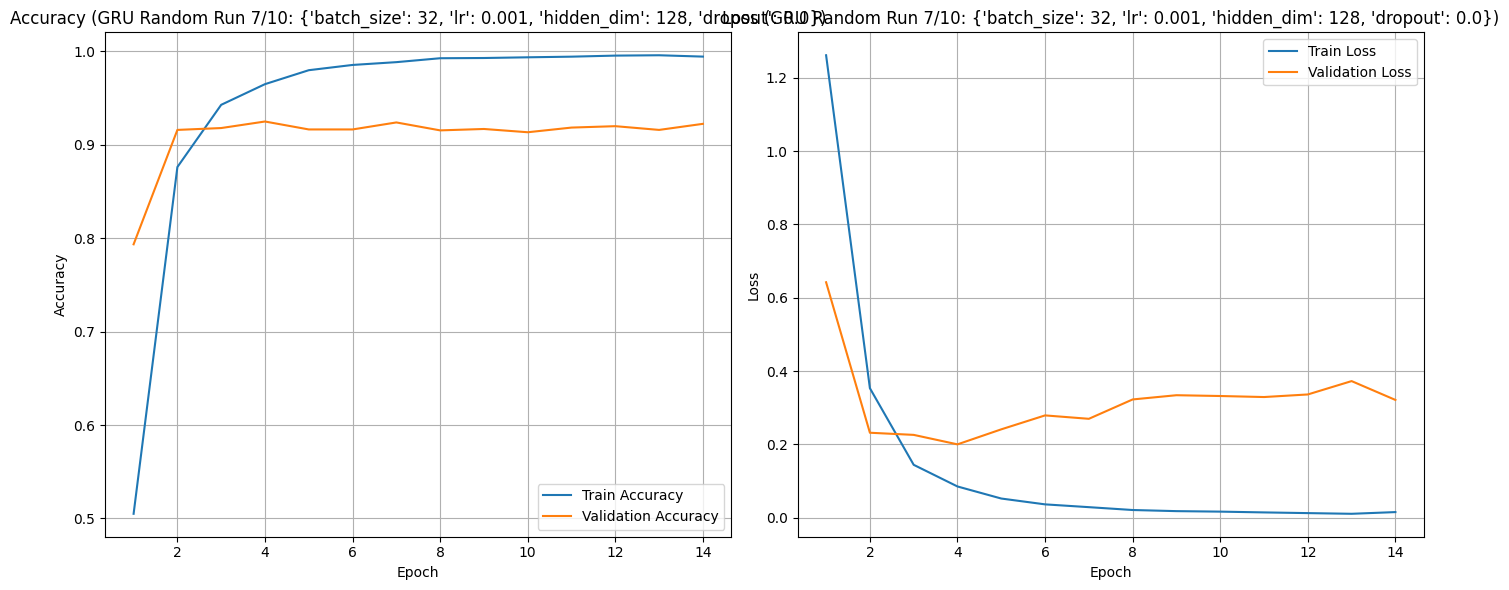


--- GRU Random Run 8/10: Params {'batch_size': 64, 'lr': 0.001, 'hidden_dim': 256, 'dropout': 0.5} ---

--- Running GRU Config: {'batch_size': 64, 'lr': 0.001, 'hidden_dim': 256, 'dropout': 0.5} ---


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]


Early stopping triggered after 43 epochs.

FINAL VALIDATION CLASSIFICATION REPORT (Best Epoch)
              precision    recall  f1-score   support

     Class 0       0.95      0.94      0.95       550
     Class 1       0.95      0.94      0.94       704
     Class 2       0.83      0.85      0.84       178
     Class 3       0.91      0.92      0.92       275
     Class 4       0.84      0.90      0.87       212
     Class 5       0.88      0.80      0.84        81

    accuracy                           0.92      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.92      0.92      0.92      2000

GRU Validation Accuracy: 0.9185


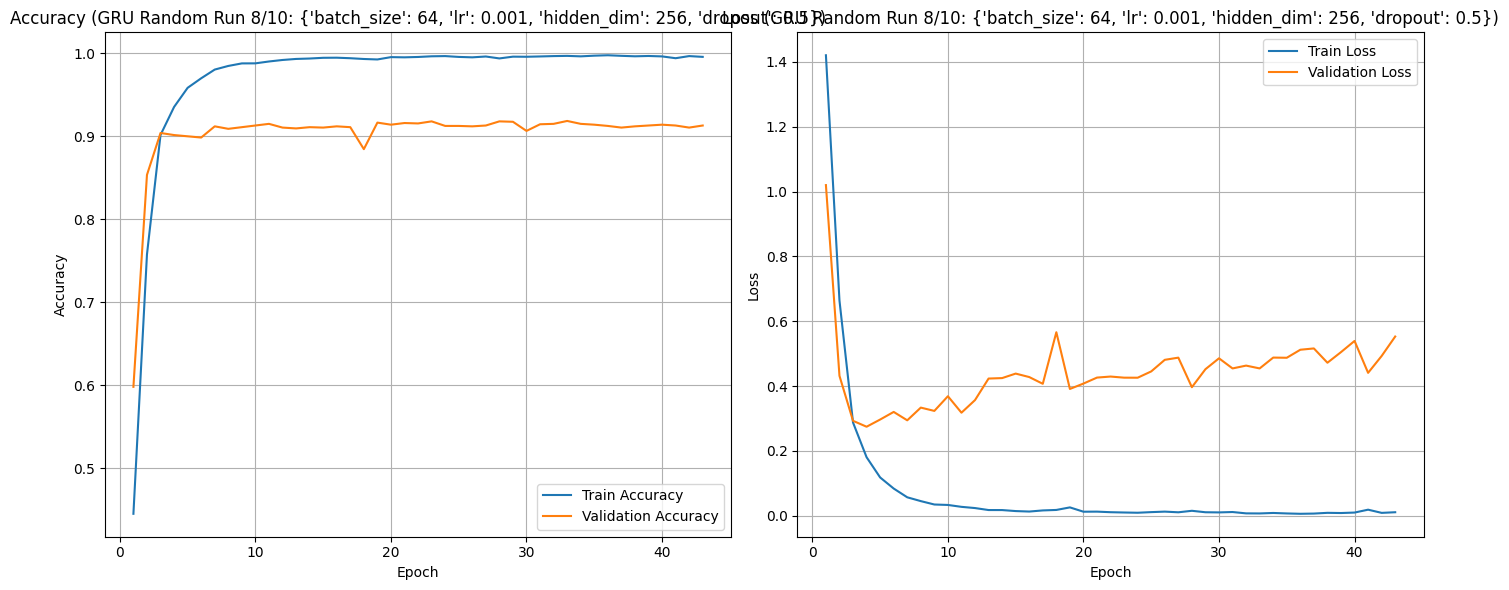


--- GRU Random Run 9/10: Params {'batch_size': 64, 'lr': 0.001, 'hidden_dim': 256, 'dropout': 0.0} ---

--- Running GRU Config: {'batch_size': 64, 'lr': 0.001, 'hidden_dim': 256, 'dropout': 0.0} ---


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]


Early stopping triggered after 31 epochs.

FINAL VALIDATION CLASSIFICATION REPORT (Best Epoch)
              precision    recall  f1-score   support

     Class 0       0.94      0.96      0.95       550
     Class 1       0.93      0.94      0.94       704
     Class 2       0.85      0.80      0.82       178
     Class 3       0.93      0.93      0.93       275
     Class 4       0.87      0.85      0.86       212
     Class 5       0.85      0.83      0.84        81

    accuracy                           0.92      2000
   macro avg       0.90      0.89      0.89      2000
weighted avg       0.92      0.92      0.92      2000

GRU Validation Accuracy: 0.9185


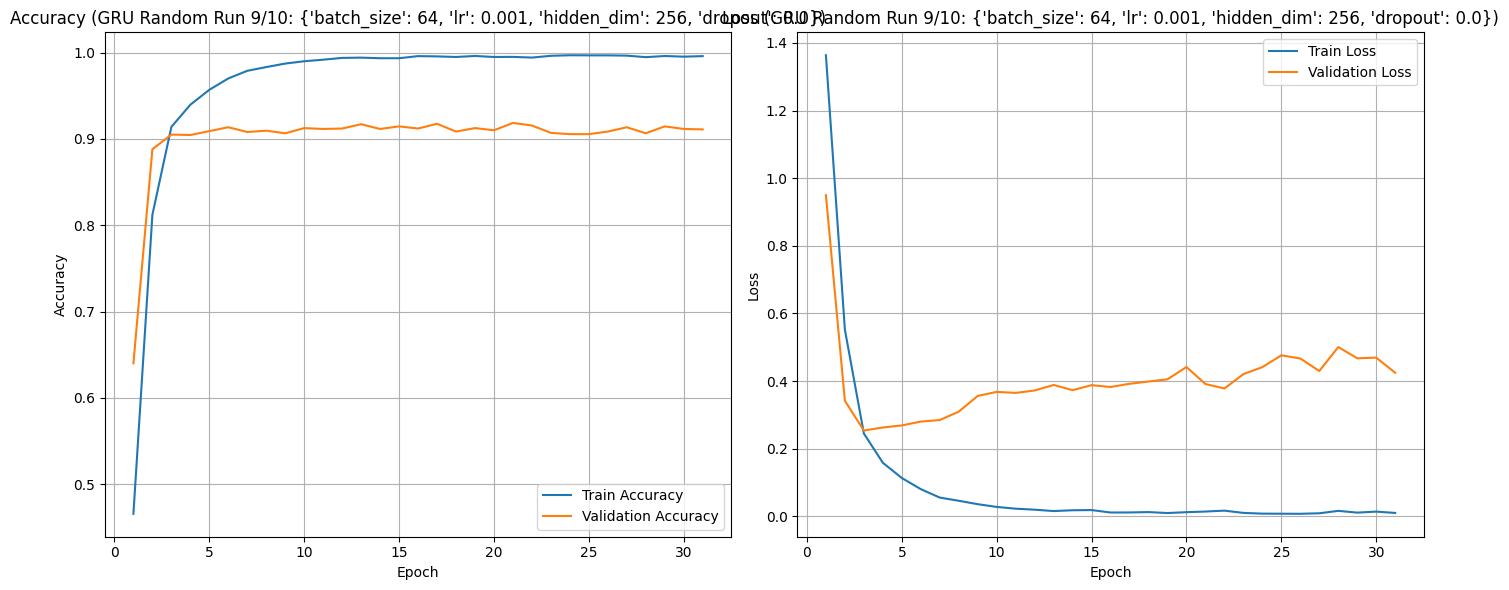


--- GRU Random Run 10/10: Params {'batch_size': 64, 'lr': 0.001, 'hidden_dim': 64, 'dropout': 0.0} ---

--- Running GRU Config: {'batch_size': 64, 'lr': 0.001, 'hidden_dim': 64, 'dropout': 0.0} ---


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]


Early stopping triggered after 17 epochs.

FINAL VALIDATION CLASSIFICATION REPORT (Best Epoch)
              precision    recall  f1-score   support

     Class 0       0.93      0.95      0.94       550
     Class 1       0.94      0.92      0.93       704
     Class 2       0.78      0.81      0.79       178
     Class 3       0.93      0.90      0.92       275
     Class 4       0.84      0.86      0.85       212
     Class 5       0.82      0.78      0.80        81

    accuracy                           0.90      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.91      0.90      0.90      2000

GRU Validation Accuracy: 0.9045


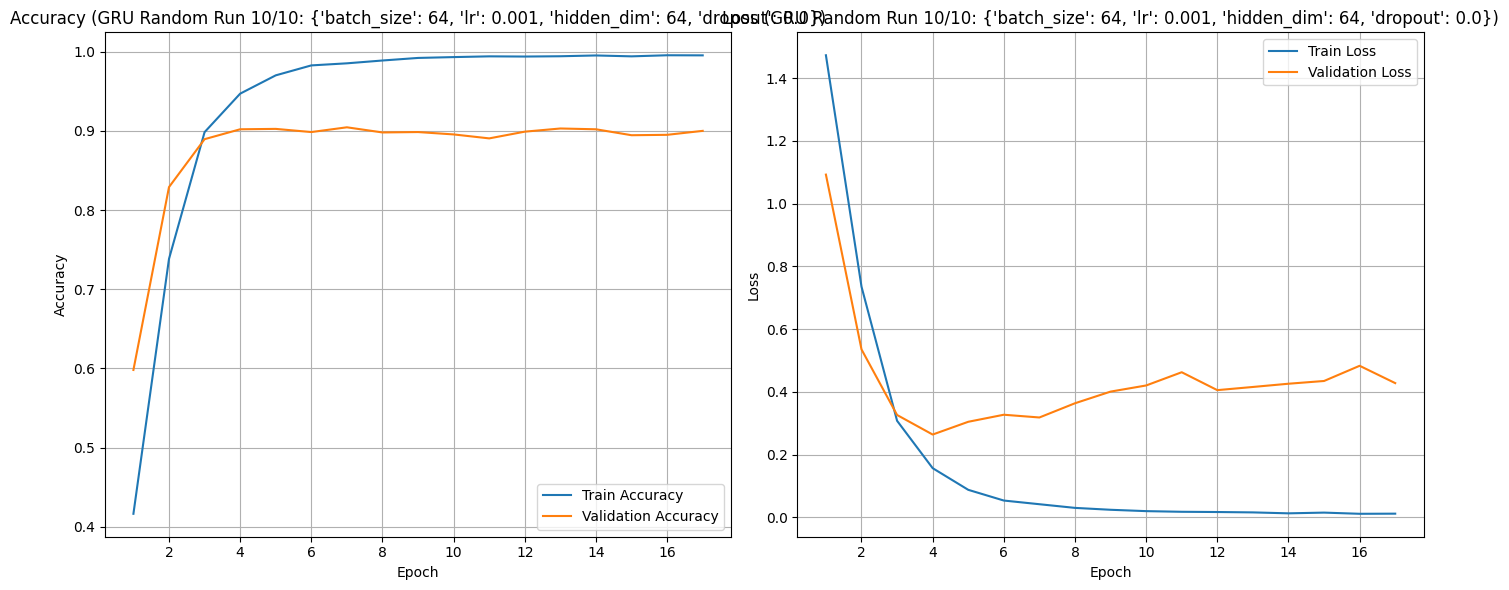

In [28]:


# --- 1. Hyperparameter Value Options ---
HYPERPARAMETERS_SPACE = {
    'batch_size': [32, 64, 128],
    'lr': [0.001, 0.005, 0.01],
    'hidden_dim': [64, 128, 256],
    'dropout': [0.0, 0.3, 0.5],

}

NUM_RANDOM_RUNS = 10

# --- 2. Generate Random Configurations ---
random_configs_gru = []
for _ in range(NUM_RANDOM_RUNS):
    config = {k: random.choice(v) for k, v in HYPERPARAMETERS_SPACE.items()}
    random_configs_gru.append(config)

print(f"Generated {NUM_RANDOM_RUNS} random configurations for GRU tuning.")

# --- 3. Run Random Search ---

best_random_val_accuracy_gru = 0.0
best_random_params_gru = None
best_random_history_gru = None
all_run_summaries_gru = []

print("\nStarting GRU Random Search Tuning...")

for i, params in enumerate(random_configs_gru):

    run_name = f"GRU Random Run {i+1}/{NUM_RANDOM_RUNS}"
    print(f"\n--- {run_name}: Params {params} ---")

    # Run the configuration using the GRU-specific runner
    current_history, current_params = run_single_config_gru(
        params,
        EMBEDDING_WEIGHTS,
        device=DEVICE
    )

    current_best_acc = max(current_history['val_acc'])
    all_run_summaries_gru.append(f"Run {i+1} Acc: {current_best_acc:.4f} | Params: {current_params}")

    # --- PLOTTING FOR CURRENT RUN ---
    epochs_run = len(current_history['train_acc'])
    epochs_range = range(1, epochs_run + 1)

    plt.figure(figsize=(14, 6))

    # Plot 1: Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, current_history['train_acc'], label='Train Accuracy')
    plt.plot(epochs_range, current_history['val_acc'], label='Validation Accuracy')
    plt.title(f'Accuracy ({run_name}: {current_params})')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # Plot 2: Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, current_history['train_loss'], label='Train Loss')
    plt.plot(epochs_range, current_history['val_loss'], label='Validation Loss')
    plt.title(f'Loss ({run_name}: {current_params})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()
    # --- END PLOTTING FOR CURRENT RUN ---

    # Check for best result
    if current_best_acc > best_random_val_accuracy_gru:
        best_random_val_accuracy_gru = current_best_acc
        best_random_params_gru = current_params
        best_random_history_gru = current_history
        print(f"New Best Validation Accuracy: {best_random_val_accuracy_gru:.4f}")

Summary


--- GRU Random Search Summary ---
Run 1 Acc: 0.9260 | Params: {'batch_size': 32, 'lr': 0.005, 'hidden_dim': 256, 'dropout': 0.5}
Run 2 Acc: 0.9285 | Params: {'batch_size': 128, 'lr': 0.005, 'hidden_dim': 256, 'dropout': 0.3}
Run 3 Acc: 0.9200 | Params: {'batch_size': 64, 'lr': 0.001, 'hidden_dim': 128, 'dropout': 0.3}
Run 4 Acc: 0.9255 | Params: {'batch_size': 128, 'lr': 0.005, 'hidden_dim': 128, 'dropout': 0.5}
Run 5 Acc: 0.9280 | Params: {'batch_size': 128, 'lr': 0.01, 'hidden_dim': 128, 'dropout': 0.5}
Run 6 Acc: 0.9235 | Params: {'batch_size': 64, 'lr': 0.01, 'hidden_dim': 128, 'dropout': 0.3}
Run 7 Acc: 0.9250 | Params: {'batch_size': 32, 'lr': 0.001, 'hidden_dim': 128, 'dropout': 0.0}
Run 8 Acc: 0.9185 | Params: {'batch_size': 64, 'lr': 0.001, 'hidden_dim': 256, 'dropout': 0.5}
Run 9 Acc: 0.9185 | Params: {'batch_size': 64, 'lr': 0.001, 'hidden_dim': 256, 'dropout': 0.0}
Run 10 Acc: 0.9045 | Params: {'batch_size': 64, 'lr': 0.001, 'hidden_dim': 64, 'dropout': 0.0}

Overall Best 

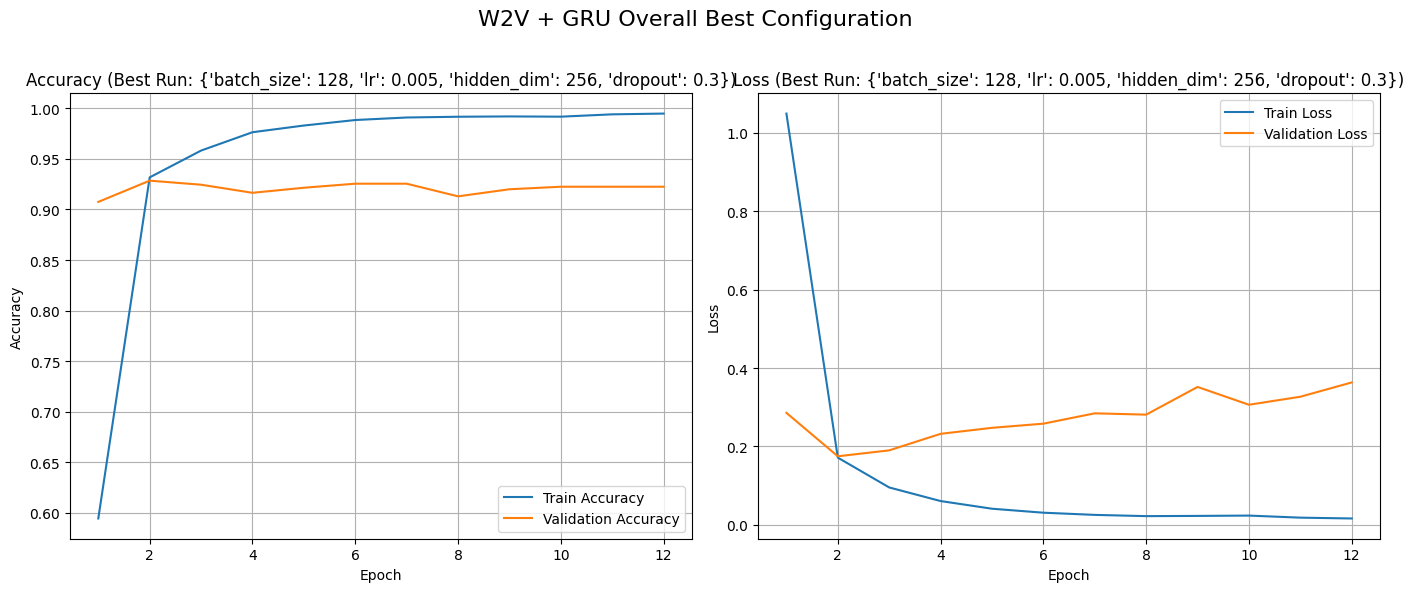

In [29]:
print("\n--- GRU Random Search Summary ---")
for summary in all_run_summaries_gru:
    print(summary)
print(f"\nOverall Best GRU Random Accuracy: {best_random_val_accuracy_gru:.4f}")
print(f"Best GRU Hyperparameters: {best_random_params_gru}")

if best_random_history_gru:
    epochs_run = len(best_random_history_gru['train_acc'])
    epochs_range = range(1, epochs_run + 1)

    plt.figure(figsize=(14, 6))
    plt.suptitle(f'W2V + GRU Overall Best Configuration', fontsize=16)

    # Plot 1: Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, best_random_history_gru['train_acc'], label='Train Accuracy')
    plt.plot(epochs_range, best_random_history_gru['val_acc'], label='Validation Accuracy')
    plt.title(f'Accuracy (Best Run: {best_random_params_gru})')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # Plot 2: Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, best_random_history_gru['train_loss'], label='Train Loss')
    plt.plot(epochs_range, best_random_history_gru['val_loss'], label='Validation Loss')
    plt.title(f'Loss (Best Run: {best_random_params_gru})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

## Train Models for Best Configurations

In [31]:
# --- 1. Define Best Configurations ---

# Best LSTM came from tuning run no. 1
BEST_LSTM_PARAMS = {'batch_size': 64, 'lr': 0.001, 'hidden_dim': 256, 'dropout': 0.3}

# Best GRU came from tuning run no. 2
BEST_GRU_PARAMS = {'batch_size': 128, 'lr': 0.005, 'hidden_dim': 256, 'dropout': 0.3}

FINAL_MAX_EPOCHS = 100
FINAL_PATIENCE = 10
MODEL_SAVE_DIR = "best_models"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# --- 2. LSTM Final Training (using GloVe embeddings) ---

print("\n--- Training Final LSTM Model ---")

# A. Setup
lstm_model = LSTMClassifier(
    VOCAB_SIZE,
    EMBEDDING_DIM,
    BEST_LSTM_PARAMS['hidden_dim'],
    NUM_CLASSES,
    BEST_LSTM_PARAMS['dropout'],
    EMBEDDING_WEIGHTS,
    bidirectional=False
).to(DEVICE)

lstm_optimizer = optim.Adam(lstm_model.parameters(), lr=BEST_LSTM_PARAMS['lr'])
lstm_criterion = nn.CrossEntropyLoss()
lstm_train_loader = DataLoader(
    train_dataset,
    batch_size=BEST_LSTM_PARAMS['batch_size'],
    shuffle=True,
    collate_fn=collate_fn
)
lstm_val_loader = lstm_train_loader

# B. Train
best_val_acc_lstm, _ = train_model(
    lstm_model,
    lstm_train_loader,
    lstm_val_loader,
    lstm_optimizer,
    lstm_criterion,
    FINAL_MAX_EPOCHS,
    FINAL_PATIENCE
)

# C. Save Model
LSTM_MODEL_PATH = os.path.join(MODEL_SAVE_DIR, "best_lstm_model.pth")
torch.save(lstm_model.state_dict(), LSTM_MODEL_PATH)
print(f"Final LSTM model saved to: {LSTM_MODEL_PATH}")




--- Training Final LSTM Model ---


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]


Early stopping triggered after 58 epochs.

FINAL VALIDATION CLASSIFICATION REPORT (Best Epoch)
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00      4666
     Class 1       1.00      1.00      1.00      5362
     Class 2       0.99      1.00      0.99      1304
     Class 3       1.00      1.00      1.00      2159
     Class 4       1.00      0.99      0.99      1937
     Class 5       0.98      0.99      0.99       572

    accuracy                           1.00     16000
   macro avg       0.99      1.00      1.00     16000
weighted avg       1.00      1.00      1.00     16000

Final LSTM model saved to: best_models/best_lstm_model.pth


In [ ]:
# --- 3. GRU Final Training (using Word2Vec embedding) ---

print("\n--- Training Final GRU Model ---")

# A. Setup
gru_model = GRUClassifier(
    VOCAB_SIZE,
    EMBEDDING_DIM,
    BEST_GRU_PARAMS['hidden_dim'],
    NUM_CLASSES,
    # Assuming EMBEDDING_WEIGHTS already holds the W2V weights as a Tensor.
    EMBEDDING_WEIGHTS,
    bidirectional=True,
    dropout=BEST_GRU_PARAMS['dropout'],
    pad_idx=word2idx[PAD_TOKEN]
).to(DEVICE)

gru_optimizer = optim.Adam(gru_model.parameters(), lr=BEST_GRU_PARAMS['lr'])
gru_criterion = nn.CrossEntropyLoss()
gru_train_loader, _ = create_dataloaders_gru(BEST_GRU_PARAMS['batch_size'])

# B. Train
best_val_acc_gru, _ = train_model(
    gru_model,
    gru_train_loader,
    gru_train_loader,
    gru_optimizer,
    gru_criterion,
    FINAL_MAX_EPOCHS,
    FINAL_PATIENCE
)

# C. Save Model
GRU_MODEL_PATH = os.path.join(MODEL_SAVE_DIR, "best_gru_model.pth")
torch.save(gru_model.state_dict(), GRU_MODEL_PATH)
print(f"Final GRU model saved to: {GRU_MODEL_PATH}")

## For Testing  

Import test.csv and then run the following blocks

In [ ]:
test_df=pd.read_csv('test.csv')
test_df.head()

In [ ]:

# Create Test Dataset and DataLoader
test_dataset = TextDataset(test_df, word2idx)
TEST_BATCH_SIZE = 128
test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)


# --- 2. Evaluation Function ---
@torch.no_grad()
def predict(model, dataloader):
    model.eval()
    all_preds = []

    for inputs, _ in dataloader:
        inputs = inputs.to(DEVICE)

        logits = model(inputs)
        _, predicted = torch.max(logits.data, 1)
        all_preds.extend(predicted.cpu().tolist())

    return all_preds

# --- 3. LSTM Evaluation ---

print("\n--- Evaluating LSTM Model ---")
# A. Load Model Structure
lstm_model_eval = LSTMClassifier(
    VOCAB_SIZE,
    EMBEDDING_DIM,
    BEST_LSTM_PARAMS['hidden_dim'],
    NUM_CLASSES,
    BEST_LSTM_PARAMS['dropout'],
    EMBEDDING_WEIGHTS,
    bidirectional=False
).to(DEVICE)
# B. Load Saved Weights
lstm_model_eval.load_state_dict(torch.load(LSTM_MODEL_PATH))

# C. Predict
lstm_predictions = predict(lstm_model_eval, test_loader)

# D. Save Results
lstm_results_df = test_df.copy()
lstm_results_df['LSTM_GloVe_Prediction'] = lstm_predictions
print(f"LSTM results DataFrame created with {len(lstm_results_df)} predictions.")


# --- 4. GRU Evaluation ---

print("\n--- Evaluating GRU Model ---")
# A. Load Model Structure (must use the same parameters)
gru_model_eval = GRUClassifier(
    VOCAB_SIZE,
    EMBEDDING_DIM,
    BEST_GRU_PARAMS['hidden_dim'],
    NUM_CLASSES,
    EMBEDDING_WEIGHTS.cpu().numpy(),
    bidirectional=True,
    dropout=BEST_GRU_PARAMS['dropout'],
    pad_idx=word2idx[PAD_TOKEN]
).to(DEVICE)
# B. Load Saved Weights
gru_model_eval.load_state_dict(torch.load(GRU_MODEL_PATH))

# C. Predict
gru_predictions = predict(gru_model_eval, test_loader)

# D. Save Results
gru_results_df = test_df.copy()
gru_results_df['GRU_W2V_Prediction'] = gru_predictions
print(f"GRU results DataFrame created with {len(gru_results_df)} predictions.")